conda install pytorch torchvision torchaudio pytorch-cuda=12.4 -c pytorch -c nvidia

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# 간단 실행 테스트
x = torch.randn(3, 3).to("cuda" if torch.cuda.is_available() else "cpu")
print("tensor device:", x.device)

PyTorch: 2.5.1
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060
tensor device: cuda:0


In [2]:
# ==================================================
# 0️⃣ 필수 라이브러리
# ==================================================
import os, math, time, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from jinja2 import Template

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

c:\Users\c\anaconda3\envs\py311_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

# ==================================================
# 1️⃣ 환경 / 파일 경로
# ==================================================
TRAIN_CSV = r"C:\ESG_Project1\file\merge_data\train.csv"
TEST_CSV  = r"C:\ESG_Project1\file\merge_data\test.csv"
SAVE_DIR  = r"C:\ESG_Project1\cnn_lstm\output"
os.makedirs(SAVE_DIR, exist_ok=True)

# ==================================================
# 2️⃣ 컬럼 / 하이퍼파라미터
# ==================================================
TIME_COL   = "일시"
GROUP_COL  = "발전구분"
TARGET_COL = "합산발전량(MWh)"
WEATHER_COLS = ["기온(°C)", "강수량(mm)", "일조(hr)", "일사(MJ/m2)"]
TIME_FEATS   = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]

SEQ_LEN, HORIZON = 168, 24
BATCH, EPOCHS    = 128, 100
LR, PATIENCE     = 1e-3, 5
DIFF_TP          = 50.0
SHAP_BATCH       = 32
EMA_ALPHA        = 0.3  # EMA smoothing

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (DEVICE.type == "cuda")
print("✅ Device:", DEVICE, "AMP:", use_amp)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

✅ Device: cuda AMP: True


In [ ]:
# -*- coding: utf-8 -*-
"""
완전 통합 스크립트 (수정판):
 - PLANT_LEVEL_TRAIN 옵션: 발전소별 개별 모델 학습
 - PARALLEL_TRAIN 옵션: 발전소별 병렬 학습 (ProcessPoolExecutor)
 - Resume, checkpoint, history, SHAP 안전모드, HTML 리포트 포함
 - per_plant_diagnose 구현 및 안정성 보강
"""
import os, math, warnings, base64, webbrowser, time, json, traceback
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn as nn, torch.optim as optim
from io import BytesIO
from jinja2 import Template
import shap

# ---------------------------
# === 고정(요청대로) ===
# ---------------------------
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ================================
# === 사용자 설정 (경로 / 하이퍼파라미터) ===
# ================================
TRAIN_CSV = r"C:\ESG_Project1\file\merge_data\train.csv"
VAL_CSV   = r"C:\ESG_Project1\file\merge_data\val.csv"
TEST_CSV  = r"C:\ESG_Project1\file\merge_data\test.csv"
SAVE_DIR  = r"C:\ESG_Project1\cnn_lstm\output"
os.makedirs(SAVE_DIR, exist_ok=True)

TIME_COL, GROUP_COL, REGION_COL, TARGET_COL = "일시", "발전구분", "지역", "합산발전량(MWh)"
WEATHER_COLS = [
    "기온(°C)", "강수량(mm)", "풍속(m/s)", "습도(%)", "증기압(hPa)",
    "일조(hr)", "일사(MJ/m2)", "적설(cm)", "전운량(10분위)",
    "중하층운량(10분위)", "최저운고(100m)"
]
TIME_FEATS = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]

SEQ_LEN, HORIZON = 168, 24
BATCH = 128
EPOCHS = 50            # 필요 시 올리세요
LR = 1e-3
PATIENCE = 7           # val R2 기준 patience
NUM_WORKERS = 0 if os.name=="nt" else 4
SMOOTH_WINDOW = 3
R2_THRESHOLD = 0.5     # 제외 기준 (요청값)
SHAP_SAMPLE = 200      # SHAP 계산 시 background sample 수 (메모리 고려)

# Device 기본값 (메인 프로세스)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (DEVICE.type=="cuda")
torch.set_num_threads(max(1, min(4, multiprocessing.cpu_count()//2)))

print(f"✅ Main Device: {DEVICE} | AMP: {use_amp}")

# ================================
# === 병렬/플랜트 옵션 ===
# ================================
PLANT_LEVEL_TRAIN = True    # True: 발전소별 개별 모델 학습. False: 지역/통합 모델 흐름.
PARALLEL_TRAIN = False      # 발전소별 병렬 학습
N_JOBS = min(4, max(1, multiprocessing.cpu_count()//2))  # 기본 프로세스 수
GPU_IDS = os.environ.get("GPU_IDS", None)  # 예: "0,1,2" 환경변수로 지정 가능
if GPU_IDS:
    GPU_IDS = [g.strip() for g in GPU_IDS.split(",") if g.strip()!=""]
else:
    GPU_IDS = [str(i) for i in range(torch.cuda.device_count())] if torch.cuda.device_count()>0 else []

print(f"🔧 PLANT_LEVEL_TRAIN={PLANT_LEVEL_TRAIN}, PARALLEL_TRAIN={PARALLEL_TRAIN}, N_JOBS={N_JOBS}, GPU_IDS={GPU_IDS}")

# ================================
# === 데이터 로드 및 피처 생성 ===
# ================================
train_raw = pd.read_csv(TRAIN_CSV, parse_dates=[TIME_COL])
val_raw   = pd.read_csv(VAL_CSV, parse_dates=[TIME_COL])
test_raw  = pd.read_csv(TEST_CSV, parse_dates=[TIME_COL])

def add_time_feats(df):
    df = df.copy()
    df.sort_values([GROUP_COL, TIME_COL], inplace=True)
    df["hour"] = df[TIME_COL].dt.hour
    df["doy"] = df[TIME_COL].dt.dayofyear
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["doy_sin"] = np.sin(2*np.pi*df["doy"]/365)
    df["doy_cos"] = np.cos(2*np.pi*df["doy"]/365)
    return df

for df in (train_raw, val_raw, test_raw):
    df[:] = add_time_feats(df)

LAGS = [1,3,6,24]
def add_lag_diff(df):
    df = df.copy()
    for lag in LAGS:
        df[f"lag_{lag}"] = df.groupby(GROUP_COL)[TARGET_COL].shift(lag)
        df[f"diff_{lag}"] = df[TARGET_COL] - df[f"lag_{lag}"]
    df.fillna(0, inplace=True)
    return df

train_raw = add_lag_diff(train_raw)
val_raw   = add_lag_diff(val_raw)
test_raw  = add_lag_diff(test_raw)

all_candidate_feats = WEATHER_COLS + TIME_FEATS + [f"lag_{l}" for l in LAGS] + [f"diff_{l}" for l in LAGS]
feature_cols = [c for c in all_candidate_feats if c in train_raw.columns]
if len(feature_cols) == 0:
    raise RuntimeError("feature_cols가 비어있습니다. 전처리(시간특성/lag/diff)가 제대로 되었는지 확인하세요.")
print(f"✅ 사용되는 feature_cols ({len(feature_cols)}개): {feature_cols}")

region_scalers = {}
for region, grp in train_raw.groupby(REGION_COL):
    valid_cols = [c for c in feature_cols if c in grp.columns]
    if len(valid_cols) == 0:
        print(f"⚠ [{region}] 유효한 피처 없음 — 이 그룹은 건너뜁니다.")
        continue
    try:
        std = StandardScaler(); mm = MinMaxScaler()
        X_std = std.fit_transform(grp[valid_cols].values)
        X_mm = mm.fit_transform(X_std)
        train_raw.loc[grp.index, valid_cols] = X_mm
        tsc = StandardScaler().fit(np.log1p(grp[[TARGET_COL]].clip(lower=0.0)+1e-8))
        train_raw.loc[grp.index, TARGET_COL] = tsc.transform(np.log1p(grp[[TARGET_COL]].clip(lower=0.0)+1e-8))
    except Exception as e:
        print(f"⚠ [{region}] 스케일링/타깃 변환 실패: {e}")
        std, mm, tsc = None, None, None
    region_scalers[region] = (std, mm, tsc)

for df in (val_raw, test_raw):
    for region, grp in df.groupby(REGION_COL):
        valid_cols = [c for c in feature_cols if c in grp.columns]
        if len(valid_cols) == 0:
            print(f"⚠ [{region}] (val/test) 유효한 피처 없음 — 스킵")
            continue
        if region in region_scalers:
            std, mm, tsc = region_scalers[region]
            if std is None or mm is None:
                try:
                    df.loc[grp.index, valid_cols] = MinMaxScaler().fit_transform(grp[valid_cols].values)
                except Exception as e:
                    print(f"⚠ [{region}] val/test 변환 실패: {e}")
                continue
            try:
                df.loc[grp.index, valid_cols] = mm.transform(std.transform(grp[valid_cols].values))
                if tsc is not None:
                    try:
                        df.loc[grp.index, TARGET_COL] = tsc.transform(np.log1p(grp[[TARGET_COL]].clip(lower=0.0)+1e-8))
                    except Exception:
                        pass
            except Exception as e:
                print(f"⚠ [{region}] val/test 변환 실패: {e} — 로컬 스케일러 사용")
                df.loc[grp.index, valid_cols] = MinMaxScaler().fit_transform(grp[valid_cols].values)
        else:
            try:
                df.loc[grp.index, valid_cols] = MinMaxScaler().fit_transform(grp[valid_cols].values)
            except Exception as e:
                print(f"⚠ [{region}] unseen region 로컬 스케일링 실패: {e}")

# ================================
# === Dataset & Model 정의 ===
# ================================
class SequenceDataset(Dataset):
    def __init__(self, df, seq_len=SEQ_LEN, horizon=HORIZON, feature_cols=feature_cols, return_index=False):
        # 안전: df가 비어있거나 feature가 없으면 최소한의 제로 윈도우를 만듦
        self.seq_len = seq_len
        self.horizon = horizon
        self.feature_cols = [c for c in feature_cols if c in df.columns]
        if len(self.feature_cols)==0:
            # fallback: zero features
            self.features = np.zeros((len(df), 1), dtype=np.float32)
        else:
            self.features = df[self.feature_cols].values.astype(np.float32)
        self.targets = df[TARGET_COL].fillna(0).values.astype(np.float32)
        self.index_arr = np.array(df.index)
        self.n_windows = max(0, len(df) - seq_len - horizon + 1)
        self.return_index = return_index
    def __len__(self):
        return self.n_windows
    def __getitem__(self, i):
        x = self.features[i:i+self.seq_len]
        y = self.targets[i+self.seq_len:i+self.seq_len+self.horizon]
        start_idx = int(self.index_arr[i+self.seq_len]) if len(self.index_arr)>i+self.seq_len else int(i+self.seq_len)
        if self.return_index:
            return torch.from_numpy(x), torch.from_numpy(y), start_idx
        else:
            return torch.from_numpy(x), torch.from_numpy(y)

class CNN_BiLSTM(nn.Module):
    def __init__(self, input_dim=None, hidden=128, num_layers=2, horizon=HORIZON):
        super().__init__()
        if input_dim is None:
            input_dim = len(feature_cols)
        self.conv1 = nn.Conv1d(input_dim, 128, 3, padding=1)
        self.conv2 = nn.Conv1d(128, 64, 3, padding=1)
        self.lstm = nn.LSTM(64, hidden, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden*2, horizon)
        self.relu = nn.ReLU()
        self.norm = nn.LayerNorm(hidden*2)
    def forward(self, x):
        # x: (B, seq_len, feat)
        x = x.permute(0,2,1)  # (B, feat, seq)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.permute(0,2,1)  # (B, seq, hidden)
        x,_ = self.lstm(x)
        x = self.norm(x[:,-1,:])
        return self.fc(x)

def safe_inverse_tsc(tsc, arr):
    try:
        arr = np.array(arr).reshape(-1,1)
        inv = tsc.inverse_transform(arr)
        return np.expm1(inv.flatten())
    except Exception:
        # if tsc missing or failed, assume arr already log1p-transformed or raw
        try:
            return np.expm1(arr.flatten())
        except Exception:
            return arr.flatten()

# ================================
# === 유틸: 재조립 / 평가 / 로그 포맷 ===
# ================================
def reassemble_predictions(model, df_region, device=DEVICE):
    n = len(df_region)
    if n==0:
        return np.array([]), np.array([])
    pred_sum = np.zeros(n, dtype=np.float64)
    pred_count = np.zeros(n, dtype=np.int32)
    true_sum = np.zeros(n, dtype=np.float64)
    true_count = np.zeros(n, dtype=np.int32)

    ds = SequenceDataset(df_region.reset_index(drop=True), return_index=True)
    if len(ds)==0:
        # not enough windows
        return np.full(n, np.nan), np.full(n, np.nan)
    loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)
    model.eval()
    with torch.no_grad():
        for batch in loader:
            if len(batch)==3:
                xb, yb, idxs = batch
            else:
                xb, yb = batch; idxs = None
            xb = xb.to(device)
            yp = model(xb).cpu().numpy()
            yb_np = yb.numpy()
            if idxs is None:
                continue
            for j, start_idx in enumerate(idxs if isinstance(idxs, np.ndarray) else idxs.numpy()):
                s = int(start_idx); e = s + HORIZON
                if s<0 or e>n: continue
                pred_sum[s:e] += yp[j]; pred_count[s:e] += 1
                true_sum[s:e] += yb_np[j]; true_count[s:e] += 1

    pred_avg = np.full(n, np.nan, dtype=np.float64)
    true_avg = np.full(n, np.nan, dtype=np.float64)
    mask = pred_count>0
    pred_avg[mask] = pred_sum[mask] / pred_count[mask]
    maskt = true_count>0
    true_avg[maskt] = true_sum[maskt] / true_count[maskt]

    pred_series = pd.Series(pred_avg)
    pred_series = pred_series.interpolate().fillna(method='ffill').fillna(method='bfill')
    pred_smoothed = pred_series.rolling(SMOOTH_WINDOW, min_periods=1, center=True).mean().values

    return true_avg, pred_smoothed

def evaluate_on_df(model, df_region, region_name, device=DEVICE):
    true_avg, pred_smoothed = reassemble_predictions(model, df_region, device=device)
    if len(true_avg)==0:
        return {"r2":float('nan'), "mae":float('nan'), "rmse":float('nan'), "n":0}, np.array([]), np.array([])
    if region_name in region_scalers:
        _, _, tsc = region_scalers[region_name]
        rec_true = np.full_like(true_avg, np.nan)
        if (~np.isnan(true_avg)).sum()>0 and tsc is not None:
            rec_true[~np.isnan(true_avg)] = safe_inverse_tsc(tsc, true_avg[~np.isnan(true_avg)])
        rec_pred = safe_inverse_tsc(tsc, pred_smoothed) if tsc is not None else pred_smoothed
    else:
        rec_true, rec_pred = true_avg, pred_smoothed

    mask = ~np.isnan(rec_true) & ~np.isnan(rec_pred)
    if mask.sum()>0:
        r2 = r2_score(rec_true[mask], rec_pred[mask])
        mae = mean_absolute_error(rec_true[mask], rec_pred[mask])
        rmse = math.sqrt(mean_squared_error(rec_true[mask], rec_pred[mask]))
    else:
        r2, mae, rmse = float('nan'), float('nan'), float('nan')
    return {"r2":r2, "mae":mae, "rmse":rmse, "n":int(mask.sum())}, rec_true, rec_pred

def log_epoch_prefix(start_time, epoch_idx, total_epochs, extra=""):
    elapsed = time.time() - start_time
    avg_per_epoch = elapsed / max(1, epoch_idx)
    remaining = max(0, total_epochs - epoch_idx) * avg_per_epoch
    return f"epoch {epoch_idx}/{total_epochs} | elapsed={elapsed:.1f}s | ETA={remaining:.1f}s {extra}"

# ================================
# === 학습 유틸: resume-aware history 저장/로드 ===
# ================================
def save_history(hist, path):
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(hist, f, ensure_ascii=False, indent=2)
    except Exception as e:
        print(f"⚠ history 저장 실패: {e}")

def load_history(path):
    if not os.path.exists(path): return []
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return []

# ================================
# === per_plant_diagnose 구현 ===
# (region-level에서 plant별 R2 계산에 사용됨)
# ================================
def per_plant_diagnose(model, train_grp, val_grp, test_grp, region_name, device=DEVICE):
    plants = sorted(train_grp[GROUP_COL].unique())
    rows = []
    low_plants = []
    for p in plants:
        tdf = train_grp[train_grp[GROUP_COL]==p].reset_index(drop=True)
        vdf = val_grp[val_grp[GROUP_COL]==p].reset_index(drop=True)
        tsdf = test_grp[test_grp[GROUP_COL]==p].reset_index(drop=True)
        if len(vdf) < SEQ_LEN + HORIZON:
            rows.append({"발전구분":p, "R2":float('nan'), "n":0})
            continue
        # eval on val using current model
        metrics, _, _ = evaluate_on_df(model, vdf, region_name if REGION_COL in vdf.columns else p, device=device)
        rows.append({"발전구분":p, "R2":metrics["r2"], "n":metrics["n"]})
        if np.isfinite(metrics["r2"]) and metrics["r2"] < R2_THRESHOLD:
            low_plants.append(p)
    plant_df = pd.DataFrame(rows)
    return plant_df, low_plants

# ================================
# === 가중치 보정 함수 (변경 없음) ===
# ================================
def compute_plant_weights_from_val(plant_df, low_weight=0.1, high_weight=1.0):
    if plant_df.empty:
        return {}
    min_r2 = plant_df["R2"].min()
    max_r2 = plant_df["R2"].max()
    denom = max(1e-6, (max_r2 - min_r2))
    plant_df = plant_df.copy()
    plant_df["r2_norm"] = (plant_df["R2"] - min_r2) / denom
    plant_df["weight_raw"] = 1.0 - plant_df["r2_norm"]
    plant_df["weight"] = plant_df["weight_raw"].clip(0.0,1.0) * (high_weight - low_weight) + low_weight
    return dict(zip(plant_df["발전구분"].astype(str), plant_df["weight"].astype(float)))

# ================================
# === Train 함수: resume, checkpoint, 로그 강화 (region/plant 공용) ===
# ================================
def train_region_model_core(train_df, val_df, region_tag, save_prefix,
                            epochs=EPOCHS, resume=False, weighted=False, plant_weights=None, device=None):
    if device is None:
        dev = DEVICE
    else:
        dev = torch.device(device)
    use_amp_local = (dev.type=="cuda")
    input_dim = len([c for c in feature_cols if c in train_df.columns]) if len(train_df)>0 else len(feature_cols)
    model = CNN_BiLSTM(input_dim=input_dim).to(dev)
    opt = optim.AdamW(model.parameters(), lr=LR)
    crit = nn.SmoothL1Loss()
    scaler = torch.amp.GradScaler(enabled=use_amp_local)
    best_val_r2 = -np.inf
    patience_cnt = 0

    # history files
    os.makedirs(os.path.join(SAVE_DIR), exist_ok=True)
    # ensure save_prefix is a basename, not a path
    basename = os.path.basename(save_prefix)
    best_path = os.path.join(SAVE_DIR, f"{basename}_best.pth")
    hist_path = os.path.join(SAVE_DIR, f"{basename}_history.json")

    history = []
    if resume:
        if os.path.exists(best_path):
            try:
                model.load_state_dict(torch.load(best_path, map_location=dev))
            except Exception:
                pass
        old_hist = load_history(hist_path)
        if old_hist:
            history = old_hist
            best_val_r2 = max([h.get("val_r2", -1e9) for h in history])
            print(f"    ↪ Resume loaded history ({len(history)} epochs). best_val_r2={best_val_r2:.4f}")

    train_ds = SequenceDataset(train_df.reset_index(drop=True), feature_cols=feature_cols)
    val_ds = SequenceDataset(val_df.reset_index(drop=True), feature_cols=feature_cols)
    if len(train_ds)==0 or len(val_ds)==0:
        print(f"⚠ [{region_tag}] train or val dataset too small -> skipping training")
        return model, history

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(dev.type=='cuda'))
    val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(dev.type=='cuda'))

    start_time = time.time()
    for ep in range(1, epochs+1):
        ep_global_idx = len(history) + 1  # resume aware index
        t0 = time.time()
        model.train()
        train_trues, train_preds = [], []
        total_loss = 0.0
        for batch in train_loader:
            xb, yb = batch
            xb, yb = xb.to(dev).float(), yb.to(dev).float()
            opt.zero_grad()
            with torch.autocast(device_type=dev.type, enabled=use_amp_local):
                yp = model(xb)
                loss = crit(yp, yb)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            total_loss += float(loss.item()) * xb.size(0)
            train_trues.append(yb.detach().cpu().numpy()); train_preds.append(yp.detach().cpu().numpy())

        # train metrics
        if len(train_trues)>0:
            train_trues = np.concatenate(train_trues).flatten()
            train_preds = np.concatenate(train_preds).flatten()
            mask_tr = ~np.isnan(train_trues) & ~np.isnan(train_preds)
            train_r2 = r2_score(train_trues[mask_tr], train_preds[mask_tr]) if mask_tr.sum()>0 else float('nan')
            train_mae = mean_absolute_error(train_trues[mask_tr], train_preds[mask_tr]) if mask_tr.sum()>0 else np.nan
            train_rmse = math.sqrt(mean_squared_error(train_trues[mask_tr], train_preds[mask_tr])) if mask_tr.sum()>0 else np.nan
        else:
            train_r2, train_mae, train_rmse = float('nan'), float('nan'), float('nan')

        # validation
        model.eval()
        val_trues, val_preds = [], []
        with torch.no_grad():
            for batch in val_loader:
                xb, yb = batch
                xb, yb = xb.to(dev).float(), yb.to(dev).float()
                yp = model(xb)
                val_trues.append(yb.cpu().numpy()); val_preds.append(yp.cpu().numpy())
        if len(val_trues)>0:
            val_trues = np.concatenate(val_trues).flatten()
            val_preds = np.concatenate(val_preds).flatten()
            mask_v = ~np.isnan(val_trues) & ~np.isnan(val_preds)
            val_r2 = r2_score(val_trues[mask_v], val_preds[mask_v]) if mask_v.sum()>0 else float('nan')
            val_mae = mean_absolute_error(val_trues[mask_v], val_preds[mask_v]) if mask_v.sum()>0 else np.nan
            val_rmse = math.sqrt(mean_squared_error(val_trues[mask_v], val_preds[mask_v])) if mask_v.sum()>0 else np.nan
        else:
            val_r2, val_mae, val_rmse = float('nan'), float('nan'), float('nan')

        avg_loss = total_loss / max(1, len(train_loader.dataset))
        history.append({"epoch":ep_global_idx, "loss":avg_loss,
                        "train_r2":train_r2, "train_mae":train_mae, "train_rmse":train_rmse,
                        "val_r2":val_r2, "val_mae":val_mae, "val_rmse":val_rmse})
        save_history(history, hist_path)

        prefix = log_epoch_prefix(start_time, ep_global_idx, epochs, "")
        improved = (not np.isnan(val_r2)) and (val_r2 > best_val_r2)
        star = " 🎯" if improved else ""
        print(f"[{region_tag}] {prefix} | Loss={avg_loss:.6f} | Train R2={train_r2:.4f} | Val R2={val_r2:.4f}{star}")

        if improved:
            best_val_r2 = val_r2
            patience_cnt = 0
            try:
                torch.save(model.state_dict(), best_path)
            except Exception as e:
                print(f"⚠ 체크포인트 저장 실패: {e}")
            print(f"    ↪ 저장됨: {os.path.basename(best_path)} (Val R2={best_val_r2:.4f})")
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"⏸ [{region_tag}] Early stopping at epoch {ep_global_idx} (no val_r2 improvement for {PATIENCE} epochs).")
                break

    # load best
    if os.path.exists(best_path):
        try:
            model.load_state_dict(torch.load(best_path, map_location=dev))
        except Exception:
            pass
    return model, history

# ================================
# === 발전소별 worker (plant-level) ===
# ================================
def train_single_plant_worker(args):
    try:
        import numpy as np, pandas as pd, torch, os, traceback, shap
        import matplotlib.pyplot as plt
        from io import BytesIO
        import seaborn as sns

        plant = args["plant"]
        train_df = args["train_df"]
        val_df = args["val_df"]
        test_df = args["test_df"]
        save_dir = args["save_dir"]
        epochs = args["epochs"]
        resume = args["resume"]
        gpu = args.get("gpu", None)
        plant_level_prefix = args.get("prefix", f"{plant}_plant")

        if gpu is not None and gpu != "":
            os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # 모델 학습
        model, history = train_region_model_core(
            train_df, val_df, plant,
            os.path.join(save_dir, plant_level_prefix),
            epochs=epochs, resume=resume,
            weighted=False, plant_weights=None,
            device=str(device)
        )

        # 테스트 평가
        region_name_for_scaler = test_df[REGION_COL].iloc[0] if REGION_COL in test_df.columns and len(test_df)>0 else plant
        test_metrics, rec_true, rec_pred = evaluate_on_df(model, test_df, region_name_for_scaler, device=device)

        shap_img_b64 = None
        outlier_shap_img_b64 = None
        outlier_count = 0

        try:
            model.eval()
            torch.backends.cudnn.enabled = False

            # ===============================
            # 샘플 데이터 준비
            # ===============================
            sample_df = train_df.sample(n=min(SHAP_SAMPLE, len(train_df)), random_state=42) if len(train_df) > 0 else train_df
            sample_ds = SequenceDataset(sample_df.reset_index(drop=True), feature_cols=feature_cols)

            sample_windows = []
            for i in range(min(50, sample_ds.n_windows)):
                xb, _ = sample_ds[i]
                sample_windows.append(xb.numpy())
            if len(sample_windows) == 0:
                sample_windows = np.zeros((1, SEQ_LEN, len(feature_cols)), dtype=np.float32)

            background = torch.tensor(np.stack(sample_windows), dtype=torch.float32, device=device)

            # ===============================
            # GradientExplainer
            # ===============================
            explainer = shap.GradientExplainer(model, background)
            shap_values = explainer.shap_values(background)
            if isinstance(shap_values, list):
                shap_values = shap_values[0]  # multi-output 처리

            shap_values = torch.tensor(shap_values, dtype=torch.float32, device=device)

            # 시퀀스, 배치 평균 → feature별 영향
            shap_mean = torch.mean(torch.abs(shap_values), dim=(0,1)).cpu().numpy()

            # ===============================
            # 전체 SHAP 시각화
            # ===============================
            plt.figure(figsize=(8,6))
            topk = min(len(feature_cols), 12)
            idxs = np.argsort(shap_mean)[-topk:][::-1].astype(int)
            feat_show = [feature_cols[i] for i in idxs]
            vals_show = shap_mean[idxs]
            plt.barh(feat_show[::-1], vals_show[::-1])
            plt.title(f"{plant} — SHAP mean (top{topk})")
            plt.tight_layout()
            buf = BytesIO()
            plt.savefig(buf, format="png")
            plt.close()
            buf.seek(0)
            shap_img_b64 = base64.b64encode(buf.read()).decode('utf-8')

            # ===============================
            # 이상치 탐지
            # ===============================
            rec_true_arr = np.array(rec_true)
            rec_pred_arr = np.array(rec_pred)
            errors = np.abs(rec_true_arr - rec_pred_arr)
            threshold = errors.mean() + 3 * errors.std()
            outlier_mask = errors > threshold
            outlier_indices = np.where(outlier_mask)[0]
            outlier_count = len(outlier_indices)

            if outlier_count > 0:
                mask_tensor = torch.tensor(outlier_indices, dtype=torch.long, device=device)
                shap_outliers = shap_values[mask_tensor]
                shap_mean_out = torch.mean(torch.abs(shap_outliers), dim=(0,1)).cpu().numpy()

                # 상위 feature 시각화
                plt.figure(figsize=(8,6))
                topk_out = min(10, len(feature_cols))
                idxs_out = np.argsort(shap_mean_out)[-topk_out:][::-1].astype(int)
                feat_show_out = [feature_cols[i] for i in idxs_out]
                vals_show_out = shap_mean_out[idxs_out]
                sns.barplot(x=vals_show_out, y=feat_show_out)
                plt.title(f"{plant} — 이상치 영향 상위 기상 feature (top{topk_out})")
                plt.tight_layout()
                buf = BytesIO()
                plt.savefig(buf, format="png")
                plt.close()
                buf.seek(0)
                outlier_shap_img_b64 = base64.b64encode(buf.read()).decode('utf-8')

        except Exception as e:
            print(f"⚠ [{plant}] SHAP/이상치 계산 실패: {e}")

        result = {
            "plant": plant,
            "r2": test_metrics.get("r2", np.nan),
            "mae": test_metrics.get("mae", np.nan),
            "rmse": test_metrics.get("rmse", np.nan),
            "n": test_metrics.get("n", 0),
            "shap_img": shap_img_b64,
            "outlier_count": outlier_count,
            "outlier_shap_img": outlier_shap_img_b64
        }
        return result

    except Exception as e:
        err = traceback.format_exc()
        print(f"❌ [{args.get('plant')}] worker 실패: {e}\n{err}")
        return {"plant": args.get("plant"), "error": str(e)}

# ================================
# === 발전소 전체 병렬 학습 함수 ===
# ================================
def train_all_plants(train_raw, val_raw, test_raw):
    plants = sorted(train_raw[GROUP_COL].unique())
    results = []
    futures = []

    print(f"\n🚀 발전소별 학습 시작 ({len(plants)}개)\n")

    if PARALLEL_TRAIN and len(plants) > 1:
        with ProcessPoolExecutor(max_workers=N_JOBS) as ex:
            for i, p in enumerate(plants):
                gpu = GPU_IDS[i % len(GPU_IDS)] if len(GPU_IDS) > 0 else None
                args = dict(
                    plant=p,
                    train_df=train_raw[train_raw[GROUP_COL]==p].copy(),
                    val_df=val_raw[val_raw[GROUP_COL]==p].copy(),
                    test_df=test_raw[test_raw[GROUP_COL]==p].copy(),
                    save_dir=SAVE_DIR,
                    epochs=EPOCHS,
                    resume=True,
                    gpu=gpu,
                    prefix=f"plant_{p}"
                )
                futures.append(ex.submit(train_single_plant_worker, args))

            for f in as_completed(futures):
                results.append(f.result())
    else:
        for i, p in enumerate(plants):
            gpu = GPU_IDS[i % len(GPU_IDS)] if len(GPU_IDS) > 0 else None
            args = dict(
                plant=p,
                train_df=train_raw[train_raw[GROUP_COL]==p].copy(),
                val_df=val_raw[val_raw[GROUP_COL]==p].copy(),
                test_df=test_raw[test_raw[GROUP_COL]==p].copy(),
                save_dir=SAVE_DIR,
                epochs=EPOCHS,
                resume=True,
                gpu=gpu,
                prefix=f"plant_{p}"
            )
            print(f'[{i + 1}] {p} 학습 중...')
            result = train_single_plant_worker(args)
            results.append(result)

    df_results = pd.DataFrame(results)
    df_results.to_csv(os.path.join(SAVE_DIR, "plant_results.csv"), index=False)
    print(f"\n📁 결과 저장 완료: {os.path.join(SAVE_DIR, 'plant_results.csv')}")
    return df_results

# ================================
# === HTML 리포트 생성 ===
# ================================
def generate_html_report(df_results):
    tpl = Template("""
    <html><head><meta charset="utf-8"><title>발전소별 결과 리포트</title></head>
    <body>
    <h2>발전소별 CNN-BiLSTM 예측 결과</h2>
    <table border="1" cellspacing="0" cellpadding="5">
    <tr><th>발전소</th><th>R2</th><th>MAE</th><th>RMSE</th><th>샘플수</th><th>SHAP</th></tr>
    {% for row in rows %}
      <tr>
        <td>{{row['plant']}}</td>
        <td>{{"%.3f"|format(row['r2']) if row['r2']==row['r2'] else "-"}}</td>
        <td>{{"%.3f"|format(row['mae']) if row['mae']==row['mae'] else "-"}}</td>
        <td>{{"%.3f"|format(row['rmse']) if row['rmse']==row['rmse'] else "-"}}</td>
        <td>{{row['n']}}</td>
        <td>{% if row['shap_img'] %}<img src="data:image/png;base64,{{row['shap_img']}}" width="300">{% else %}-{% endif %}</td>
      </tr>
    {% endfor %}
    </table></body></html>
    """)
    html_str = tpl.render(rows=df_results.to_dict("records"))
    html_path = os.path.join(SAVE_DIR, "plant_report.html")
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html_str)
    print(f"✅ HTML 리포트 생성 완료: {html_path}")
    webbrowser.open("file://" + html_path)

# ================================
# === 실행부 (main) ===
# ================================
if __name__ == "__main__":
    start = time.time()
    try:
        if PLANT_LEVEL_TRAIN:
            df_results = train_all_plants(train_raw, val_raw, test_raw)
            generate_html_report(df_results)
        else:
            print("⚠ 현재는 발전소별(plant-level) 모드만 활성화되어 있습니다.")
    except Exception as e:
        print(f"❌ 실행 중 오류 발생: {e}")
        traceback.print_exc()
    print(f"\n🏁 전체 완료! 총 소요시간: {(time.time()-start)/60:.1f}분")


✅ Main Device: cuda | AMP: True
🔧 PLANT_LEVEL_TRAIN=True, PARALLEL_TRAIN=False, N_JOBS=4, GPU_IDS=['0']
✅ 사용되는 feature_cols (18개): ['기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', '증기압(hPa)', '일조(hr)', '일사(MJ/m2)', '적설(cm)', '전운량(10분위)', '중하층운량(10분위)', 'lag_1', 'lag_3', 'lag_6', 'lag_24', 'diff_1', 'diff_3', 'diff_6', 'diff_24']

🚀 발전소별 학습 시작 (19개)

[0] 남제주소내 학습 중...


✅ Device: cuda | AMP: True
✅ 사용되는 feature_cols (12개): ['기온(°C)', '강수량(mm)', '일조(hr)', '일사(MJ/m2)', 'lag_1', 'lag_3', 'lag_6', 'lag_24', 'diff_1', 'diff_3', 'diff_6', 'diff_24']

################################################################################
🌍 처리 시작: 고산
[고산] Epoch 001 | Loss=0.119452 | Train R2=0.6410 | Val R2=0.6626 🎯
    ↪ 저장됨: 고산_initial_best.pth (Val R2=0.6626)
[고산] Epoch 002 | Loss=0.089453 | Train R2=0.7532 | Val R2=0.6632 🎯
    ↪ 저장됨: 고산_initial_best.pth (Val R2=0.6632)
[고산] Epoch 003 | Loss=0.083818 | Train R2=0.7683 | Val R2=0.6931 🎯
    ↪ 저장됨: 고산_initial_best.pth (Val R2=0.6931)
[고산] Epoch 004 | Loss=0.079747 | Train R2=0.7794 | Val R2=0.7020 🎯
    ↪ 저장됨: 고산_initial_best.pth (Val R2=0.7020)
[고산] Epoch 005 | Loss=0.078759 | Train R2=0.7825 | Val R2=0.7024 🎯
    ↪ 저장됨: 고산_initial_best.pth (Val R2=0.7024)
[고산] Epoch 006 | Loss=0.075754 | Train R2=0.7905 | Val R2=0.7038 🎯
    ↪ 저장됨: 고산_initial_best.pth (Val R2=0.7038)
[고산] Epoch 007 | Loss=0.074360 | Train R2=0.7

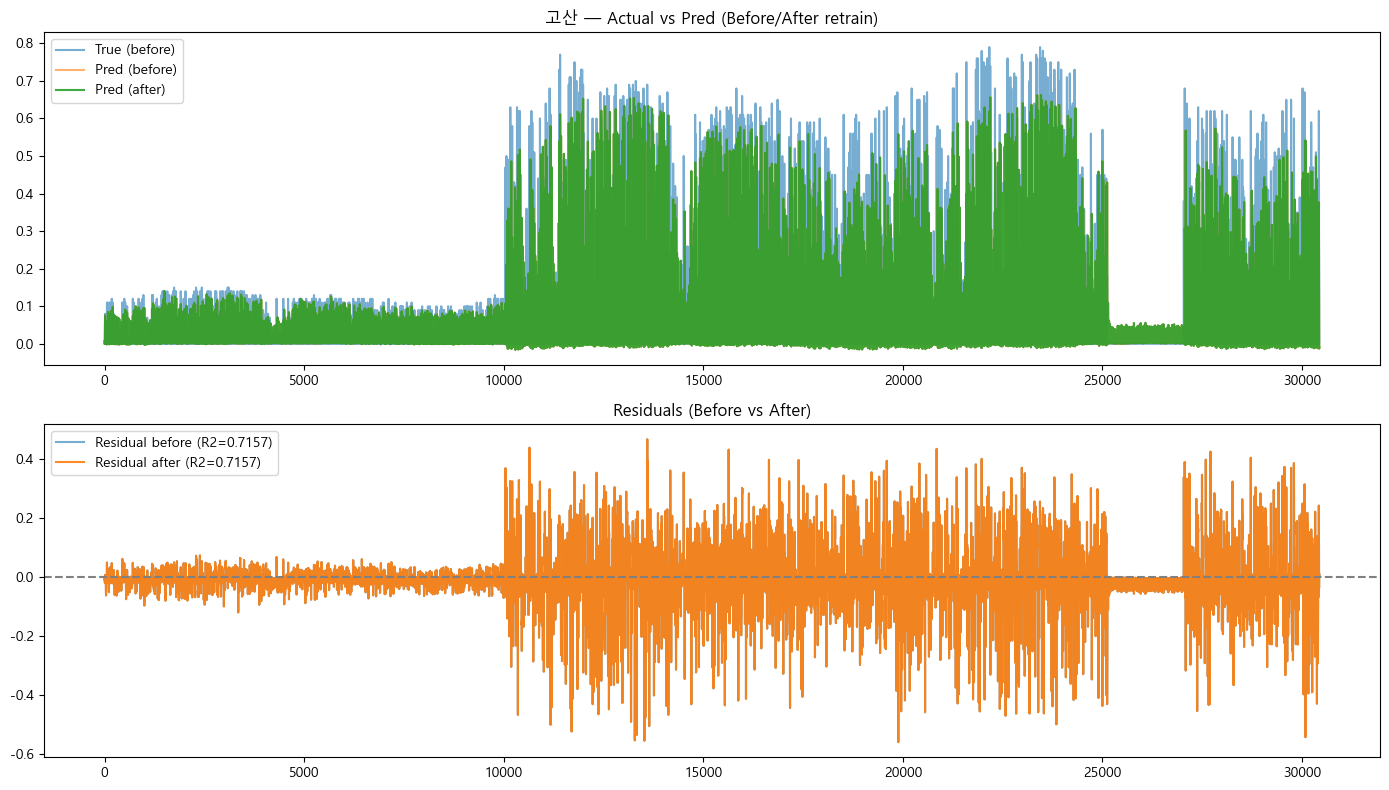

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 광양시
[광양시] Epoch 001 | Loss=0.058995 | Train R2=0.8245 | Val R2=0.8788 🎯
    ↪ 저장됨: 광양시_initial_best.pth (Val R2=0.8788)
[광양시] Epoch 002 | Loss=0.043327 | Train R2=0.8757 | Val R2=0.8871 🎯
    ↪ 저장됨: 광양시_initial_best.pth (Val R2=0.8871)
[광양시] Epoch 003 | Loss=0.040962 | Train R2=0.8825 | Val R2=0.8929 🎯
    ↪ 저장됨: 광양시_initial_best.pth (Val R2=0.8929)
[광양시] Epoch 004 | Loss=0.040679 | Train R2=0.8832 | Val R2=0.8908
[광양시] Epoch 005 | Loss=0.040019 | Train R2=0.8853 | Val R2=0.8878
[광양시] Epoch 006 | Loss=0.039769 | Train R2=0.8860 | Val R2=0.8930 🎯
    ↪ 저장됨: 광양시_initial_best.pth (Val R2=0.8930)
[광양시] Epoch 007 | Loss=0.039985 | Train R2=0.8853 | Val R2=0.8789
[광양시] Epoch 008 | Loss=0.038712 | Train R2=0.8888 | Val R2=0.8937 🎯
    ↪ 저장됨: 광양시_initial_best.pth (Val R2=0.8937)
[광양시] Epoch 009 | Loss=0.039258 | Train R2=0.8875 | Val R2=0

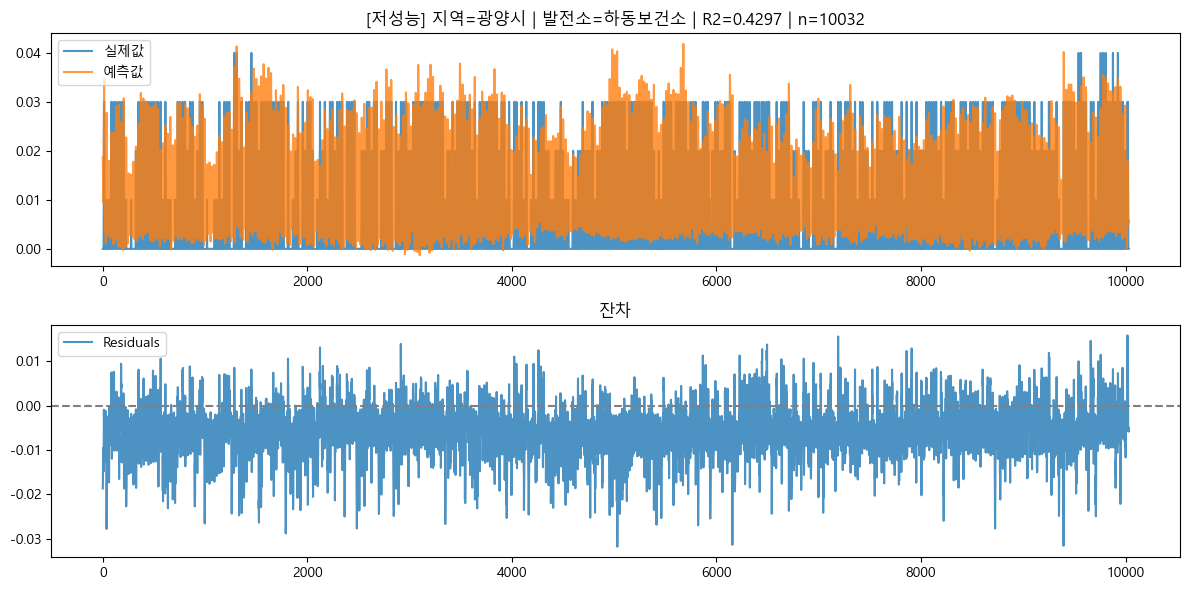

🔍 원인 분석 — 광양시 / 하동보건소
   • True mean=0.006, std=0.010, skew=1.482
   • MAE=0.006, RMSE=0.007
   • 제안: 데이터 품질 확인, 입력 피처(기상·운영) 추가 또는 발전소별 모델 검토

[광양시] 발전소별 요약 (하위 10):
   발전구분       R2      MAE     RMSE     n
  하동보건소 0.429703 0.005781 0.007348 10032
  하동변전소 0.544706 0.005751 0.007352 10032
하동하수처리장 0.641590 0.005803 0.007552 10032
  하동정수장 0.715250 0.006642 0.009201 10032
하동공설운동장 0.775565 0.017203 0.029808 10032
화촌주민참여형 0.777198 0.059926 0.112927 10032
   하동본부 0.826136 0.293093 0.542150 10032
🔁 재학습: 광양시에서 저성능 발전소 1개 제외 -> ['하동보건소']
[광양시_retrain] Epoch 001 | Loss=0.071387 | Train R2=0.8199 | Val R2=0.8663 🎯
    ↪ 저장됨: 광양시_retrain_best.pth (Val R2=0.8663)
[광양시_retrain] Epoch 002 | Loss=0.053499 | Train R2=0.8701 | Val R2=0.8778 🎯
    ↪ 저장됨: 광양시_retrain_best.pth (Val R2=0.8778)
[광양시_retrain] Epoch 003 | Loss=0.049629 | Train R2=0.8793 | Val R2=0.8926 🎯
    ↪ 저장됨: 광양시_retrain_best.pth (Val R2=0.8926)
[광양시_retrain] Epoch 004 | Loss=0.048735 | Train R2=0.8815 | Val R2=0.8944 🎯
    ↪ 저장됨: 광양시_re

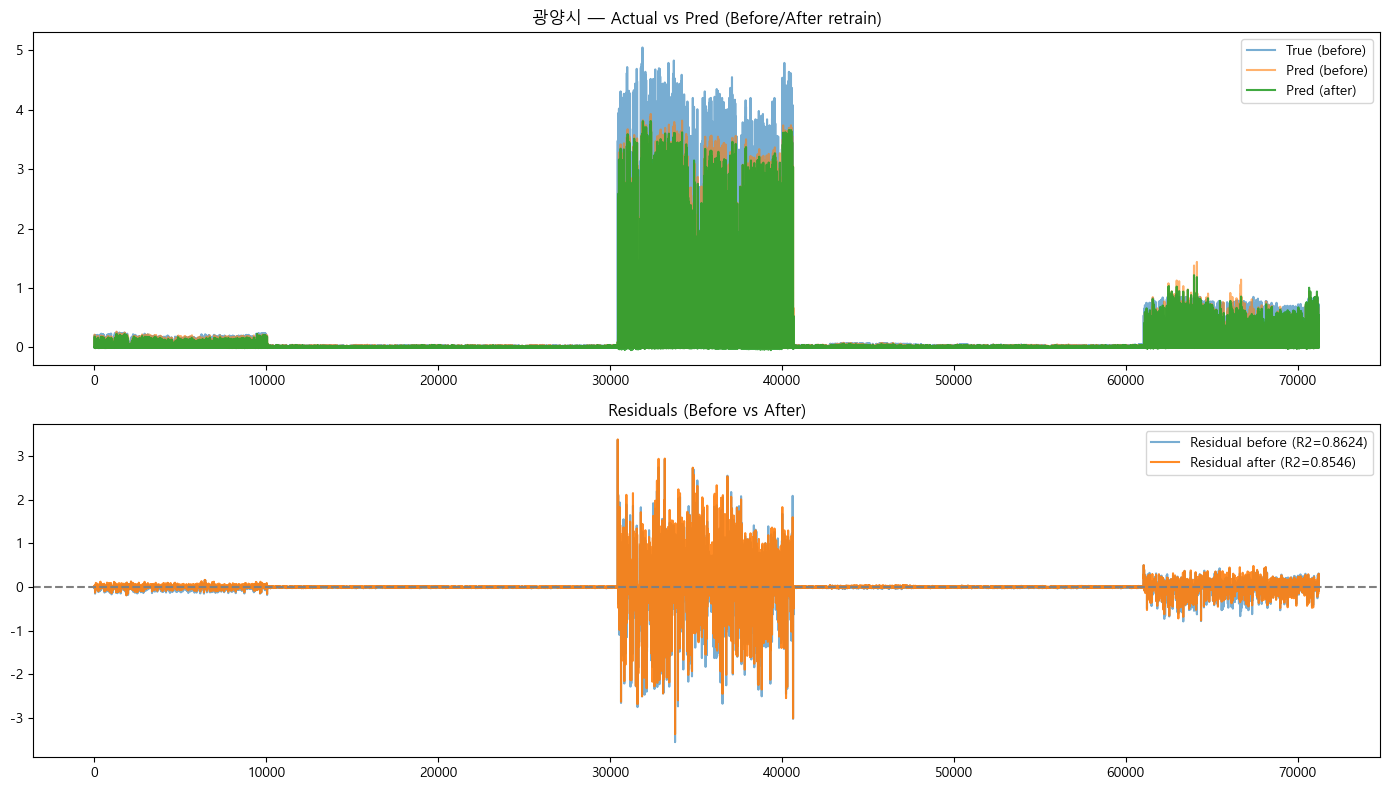

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 부산
[부산] Epoch 001 | Loss=0.075027 | Train R2=0.7864 | Val R2=0.8336 🎯
    ↪ 저장됨: 부산_initial_best.pth (Val R2=0.8336)
[부산] Epoch 002 | Loss=0.056470 | Train R2=0.8450 | Val R2=0.8584 🎯
    ↪ 저장됨: 부산_initial_best.pth (Val R2=0.8584)
[부산] Epoch 003 | Loss=0.053706 | Train R2=0.8525 | Val R2=0.8614 🎯
    ↪ 저장됨: 부산_initial_best.pth (Val R2=0.8614)
[부산] Epoch 004 | Loss=0.052459 | Train R2=0.8561 | Val R2=0.8620 🎯
    ↪ 저장됨: 부산_initial_best.pth (Val R2=0.8620)
[부산] Epoch 005 | Loss=0.050662 | Train R2=0.8607 | Val R2=0.8642 🎯
    ↪ 저장됨: 부산_initial_best.pth (Val R2=0.8642)
[부산] Epoch 006 | Loss=0.050635 | Train R2=0.8610 | Val R2=0.8631
[부산] Epoch 007 | Loss=0.048998 | Train R2=0.8655 | Val R2=0.8677 🎯
    ↪ 저장됨: 부산_initial_best.pth (Val R2=0.8677)
[부산] Epoch 008 | Loss=0.048803 | Train R2=0.8666 | Val R2=0.8652
[부산] Epoch 009 | Loss=0.0

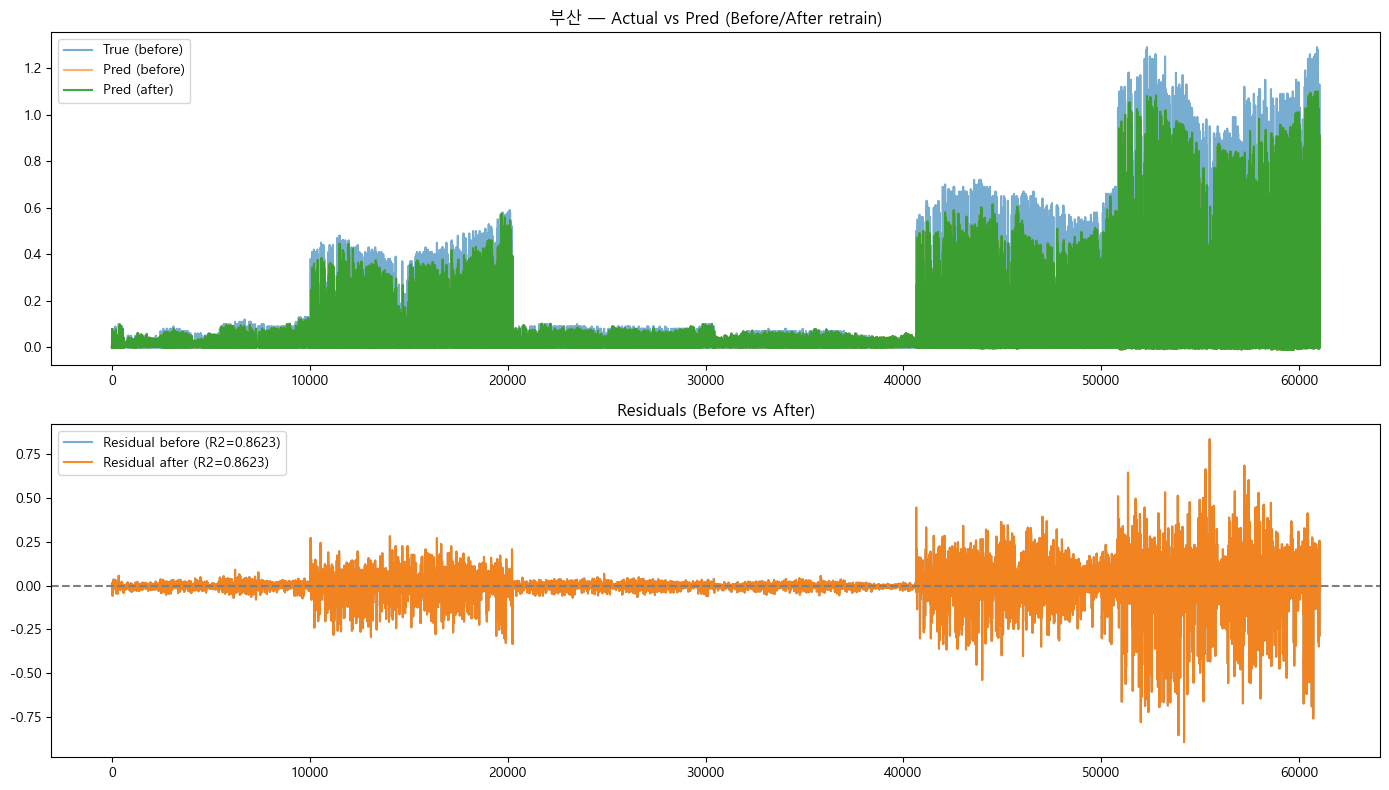

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 서귀포
[서귀포] Epoch 001 | Loss=0.247135 | Train R2=0.4046 | Val R2=0.5343 🎯
    ↪ 저장됨: 서귀포_initial_best.pth (Val R2=0.5343)
[서귀포] Epoch 002 | Loss=0.153911 | Train R2=0.6499 | Val R2=0.5788 🎯
    ↪ 저장됨: 서귀포_initial_best.pth (Val R2=0.5788)
[서귀포] Epoch 003 | Loss=0.143933 | Train R2=0.6729 | Val R2=0.5971 🎯
    ↪ 저장됨: 서귀포_initial_best.pth (Val R2=0.5971)
[서귀포] Epoch 004 | Loss=0.140018 | Train R2=0.6823 | Val R2=0.5885
[서귀포] Epoch 005 | Loss=0.135526 | Train R2=0.6928 | Val R2=0.5960
[서귀포] Epoch 006 | Loss=0.133026 | Train R2=0.6991 | Val R2=0.5851
[서귀포] Epoch 007 | Loss=0.130231 | Train R2=0.7060 | Val R2=0.5928
[서귀포] Epoch 008 | Loss=0.127101 | Train R2=0.7133 | Val R2=0.5889
[서귀포] Epoch 009 | Loss=0.124301 | Train R2=0.7196 | Val R2=0.5762
[서귀포] Epoch 010 | Loss=0.121845 | Train R2=0.7253 | Val R2=0.5675
⏸ [서귀포] Early stopping at ep

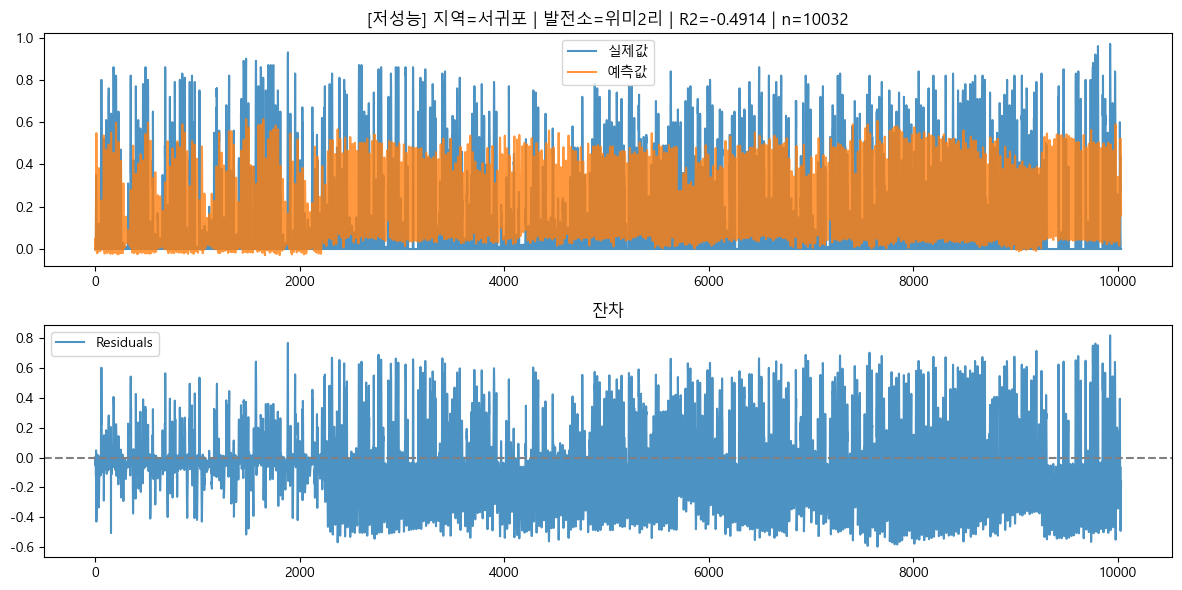

🔍 원인 분석 — 서귀포 / 위미2리
   • True mean=0.131, std=0.219, skew=1.703
   • MAE=0.205, RMSE=0.268
   • 제안: 데이터 품질 확인, 입력 피처(기상·운영) 추가 또는 발전소별 모델 검토

[서귀포] 발전소별 요약 (하위 10):
발전구분        R2      MAE    RMSE     n
위미2리 -0.491406 0.205232 0.26769 10032
🔁 재학습: 서귀포에서 저성능 발전소 1개 제외 -> ['위미2리']
   ⛔ 제외 후 학습 데이터가 부족하여 재학습을 진행할 수 없습니다. 초기 모델 유지.
📈 [서귀포] R2 before=-0.4914 → after=-0.4914 | MAE before=0.205 → after=0.205


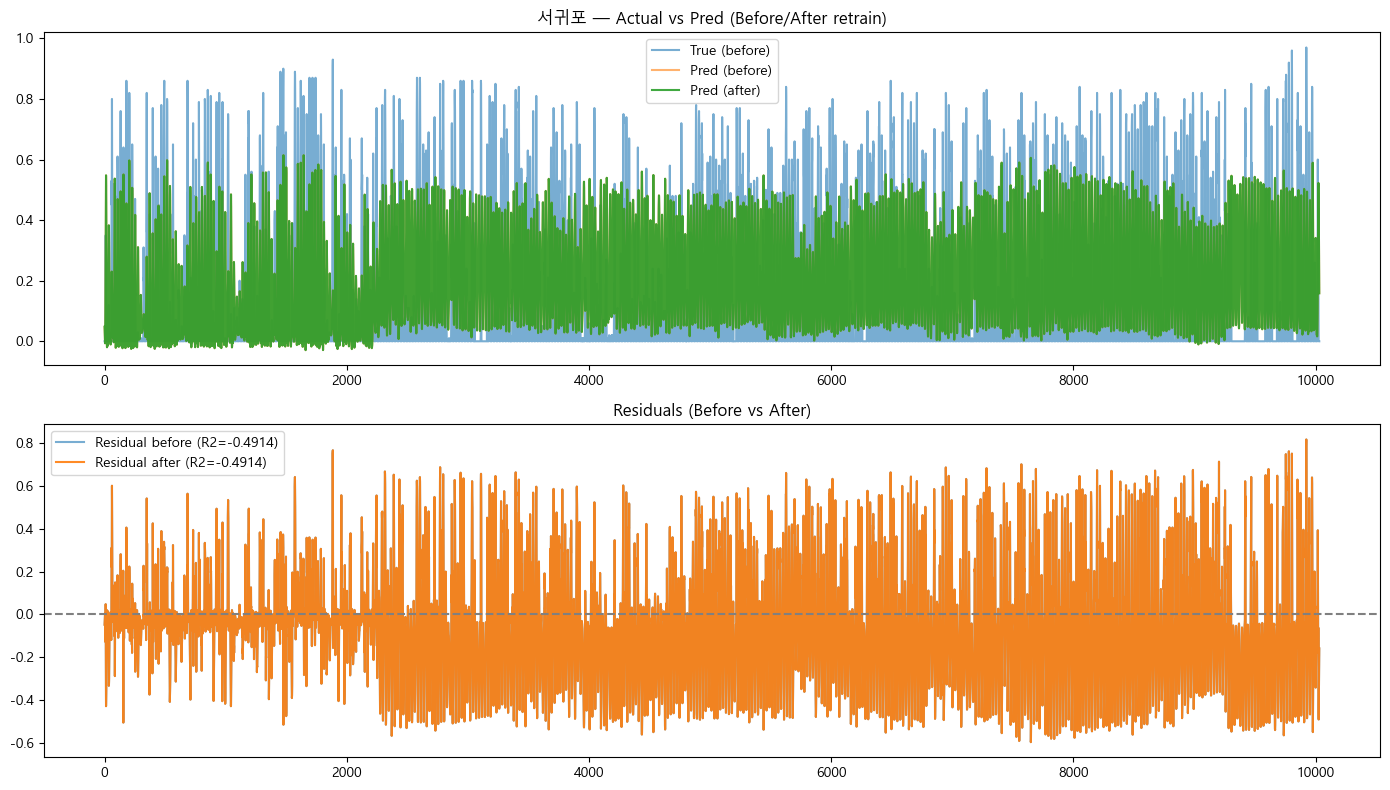

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 성산
[성산] Epoch 001 | Loss=0.106444 | Train R2=0.6524 | Val R2=0.6514 🎯
    ↪ 저장됨: 성산_initial_best.pth (Val R2=0.6514)
[성산] Epoch 002 | Loss=0.083367 | Train R2=0.7467 | Val R2=0.6549 🎯
    ↪ 저장됨: 성산_initial_best.pth (Val R2=0.6549)
[성산] Epoch 003 | Loss=0.078432 | Train R2=0.7634 | Val R2=0.6626 🎯
    ↪ 저장됨: 성산_initial_best.pth (Val R2=0.6626)
[성산] Epoch 004 | Loss=0.076116 | Train R2=0.7714 | Val R2=0.6569
[성산] Epoch 005 | Loss=0.074729 | Train R2=0.7755 | Val R2=0.6627 🎯
    ↪ 저장됨: 성산_initial_best.pth (Val R2=0.6627)
[성산] Epoch 006 | Loss=0.072019 | Train R2=0.7837 | Val R2=0.6574
[성산] Epoch 007 | Loss=0.071562 | Train R2=0.7854 | Val R2=0.6346
[성산] Epoch 008 | Loss=0.069683 | Train R2=0.7911 | Val R2=0.6637 🎯
    ↪ 저장됨: 성산_initial_best.pth (Val R2=0.6637)
[성산] Epoch 009 | Loss=0.068621 | Train R2=0.7949 | Val R2=0.6417
[성산] Epoc

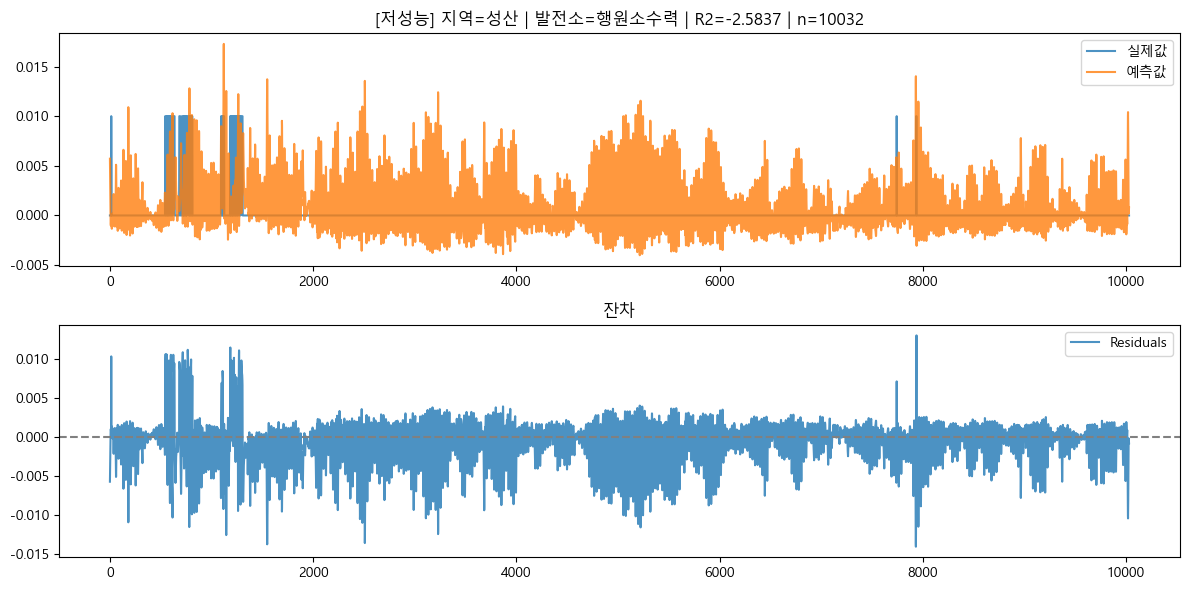

🔍 원인 분석 — 성산 / 행원소수력
   • True mean=0.000, std=0.002, skew=6.346
   • MAE=0.002, RMSE=0.003
   • 제안: 데이터 품질 확인, 입력 피처(기상·운영) 추가 또는 발전소별 모델 검토

[성산] 발전소별 요약 (하위 10):
 발전구분        R2      MAE     RMSE     n
행원소수력 -2.583713 0.001964 0.002845 10032
  송당리  0.612747 0.064322 0.124213 10032
  신풍리  0.621910 0.063285 0.123266 10032
  세화리  0.622182 0.065881 0.125858 12960
🔁 재학습: 성산에서 저성능 발전소 1개 제외 -> ['행원소수력']
[성산_retrain] Epoch 001 | Loss=0.494291 | Train R2=0.4925 | Val R2=0.6242 🎯
    ↪ 저장됨: 성산_retrain_best.pth (Val R2=0.6242)
[성산_retrain] Epoch 002 | Loss=0.357149 | Train R2=0.6668 | Val R2=0.6430 🎯
    ↪ 저장됨: 성산_retrain_best.pth (Val R2=0.6430)
[성산_retrain] Epoch 003 | Loss=0.338044 | Train R2=0.6861 | Val R2=0.6375
[성산_retrain] Epoch 004 | Loss=0.328302 | Train R2=0.6971 | Val R2=0.6286
[성산_retrain] Epoch 005 | Loss=0.320826 | Train R2=0.7055 | Val R2=0.6518 🎯
    ↪ 저장됨: 성산_retrain_best.pth (Val R2=0.6518)
[성산_retrain] Epoch 006 | Loss=0.313630 | Train R2=0.7126 | Val R2=0.6461
[성산_retrain

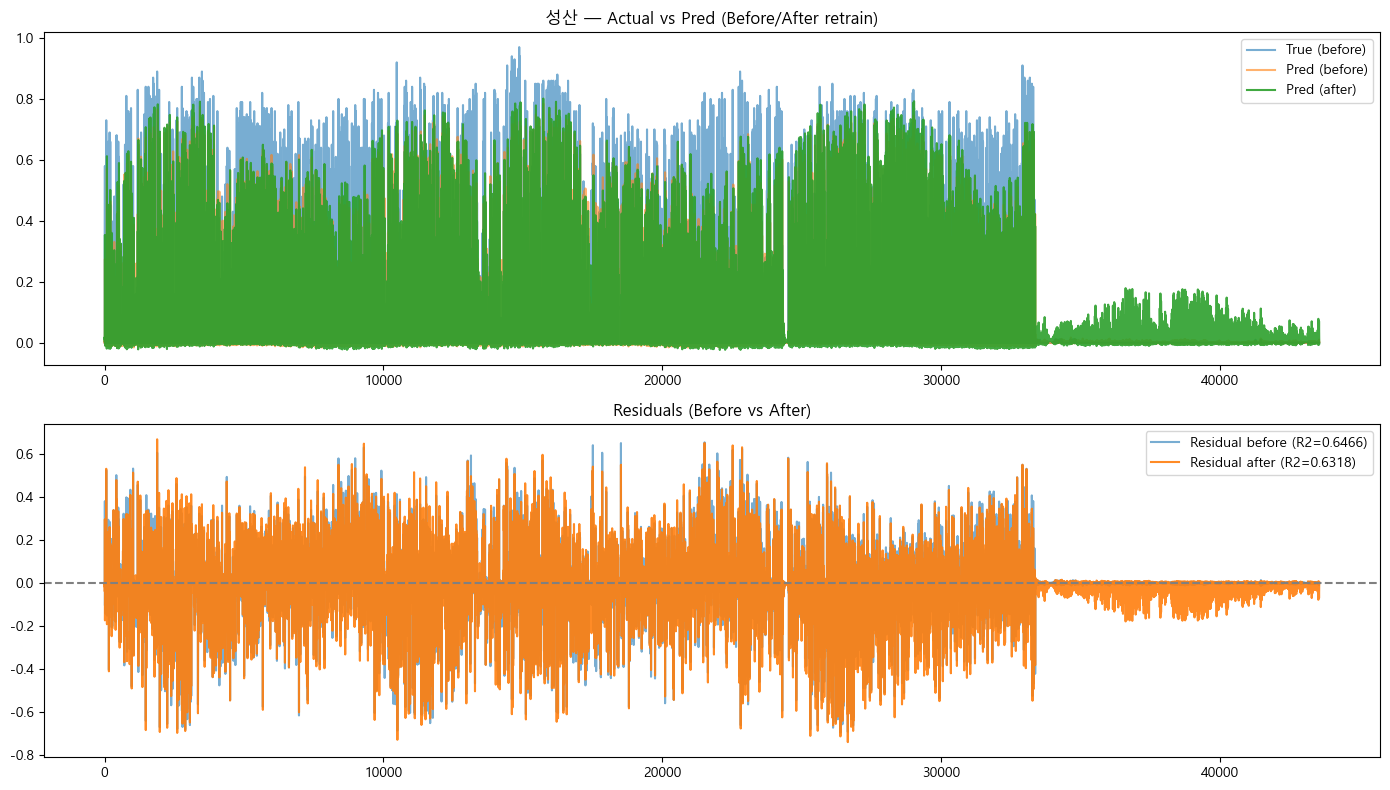

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 영월
[영월] Epoch 001 | Loss=0.156978 | Train R2=0.6482 | Val R2=0.7381 🎯
    ↪ 저장됨: 영월_initial_best.pth (Val R2=0.7381)
[영월] Epoch 002 | Loss=0.106255 | Train R2=0.7690 | Val R2=0.7894 🎯
    ↪ 저장됨: 영월_initial_best.pth (Val R2=0.7894)
[영월] Epoch 003 | Loss=0.099857 | Train R2=0.7825 | Val R2=0.7851
[영월] Epoch 004 | Loss=0.095775 | Train R2=0.7912 | Val R2=0.8020 🎯
    ↪ 저장됨: 영월_initial_best.pth (Val R2=0.8020)
[영월] Epoch 005 | Loss=0.092845 | Train R2=0.7977 | Val R2=0.8044 🎯
    ↪ 저장됨: 영월_initial_best.pth (Val R2=0.8044)
[영월] Epoch 006 | Loss=0.090666 | Train R2=0.8025 | Val R2=0.8030
[영월] Epoch 007 | Loss=0.089786 | Train R2=0.8043 | Val R2=0.8052 🎯
    ↪ 저장됨: 영월_initial_best.pth (Val R2=0.8052)
[영월] Epoch 008 | Loss=0.087983 | Train R2=0.8084 | Val R2=0.8014
[영월] Epoch 009 | Loss=0.085436 | Train R2=0.8138 | Val R2=0.8076 🎯
    ↪ 저

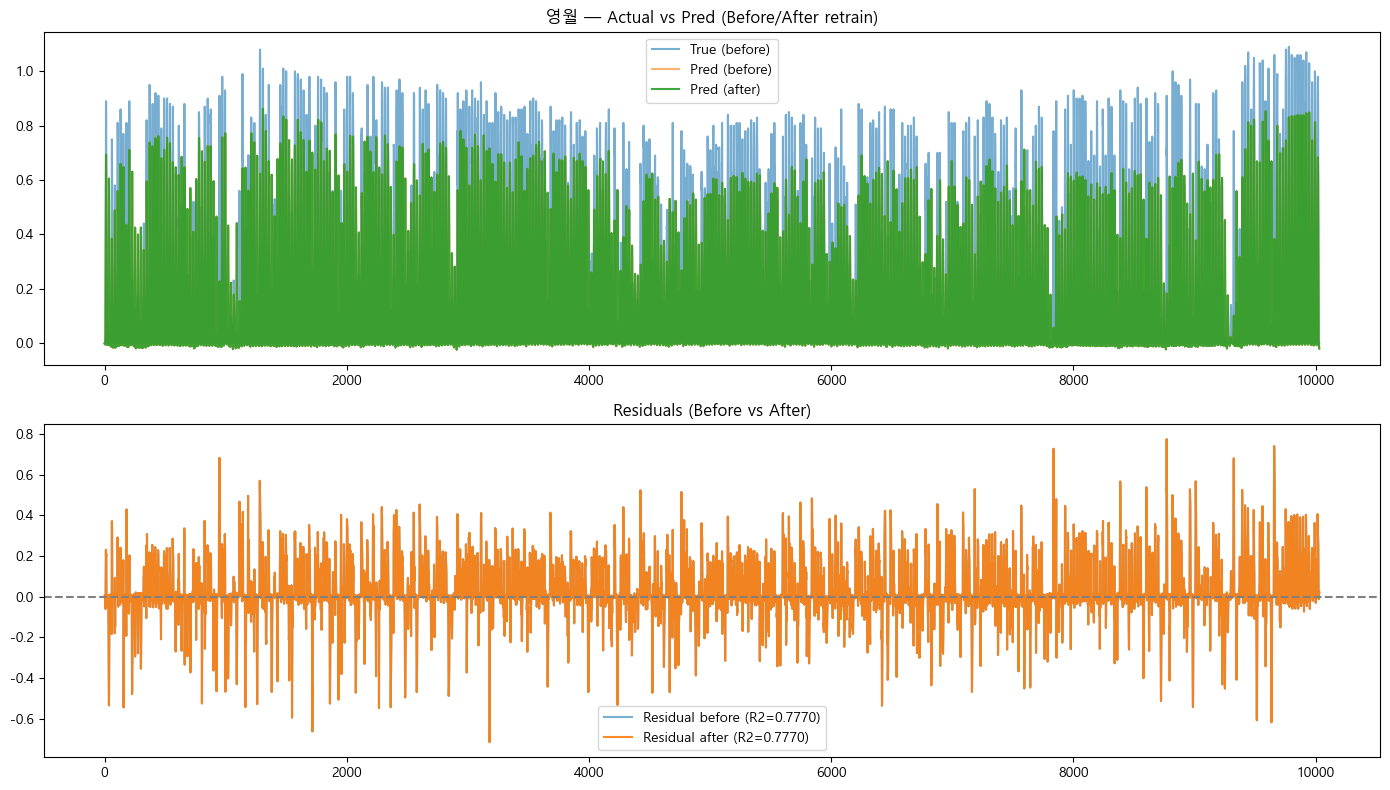

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 울진
[울진] Epoch 001 | Loss=0.141507 | Train R2=0.6846 | Val R2=0.8077 🎯
    ↪ 저장됨: 울진_initial_best.pth (Val R2=0.8077)
[울진] Epoch 002 | Loss=0.084283 | Train R2=0.8213 | Val R2=0.8282 🎯
    ↪ 저장됨: 울진_initial_best.pth (Val R2=0.8282)
[울진] Epoch 003 | Loss=0.078944 | Train R2=0.8324 | Val R2=0.8318 🎯
    ↪ 저장됨: 울진_initial_best.pth (Val R2=0.8318)
[울진] Epoch 004 | Loss=0.074730 | Train R2=0.8413 | Val R2=0.8439 🎯
    ↪ 저장됨: 울진_initial_best.pth (Val R2=0.8439)
[울진] Epoch 005 | Loss=0.071232 | Train R2=0.8488 | Val R2=0.8389
[울진] Epoch 006 | Loss=0.068918 | Train R2=0.8538 | Val R2=0.8507 🎯
    ↪ 저장됨: 울진_initial_best.pth (Val R2=0.8507)
[울진] Epoch 007 | Loss=0.067284 | Train R2=0.8573 | Val R2=0.8506
[울진] Epoch 008 | Loss=0.065045 | Train R2=0.8620 | Val R2=0.8468
[울진] Epoch 009 | Loss=0.063151 | Train R2=0.8661 | Val R2=0.8484
[울진] Epoc

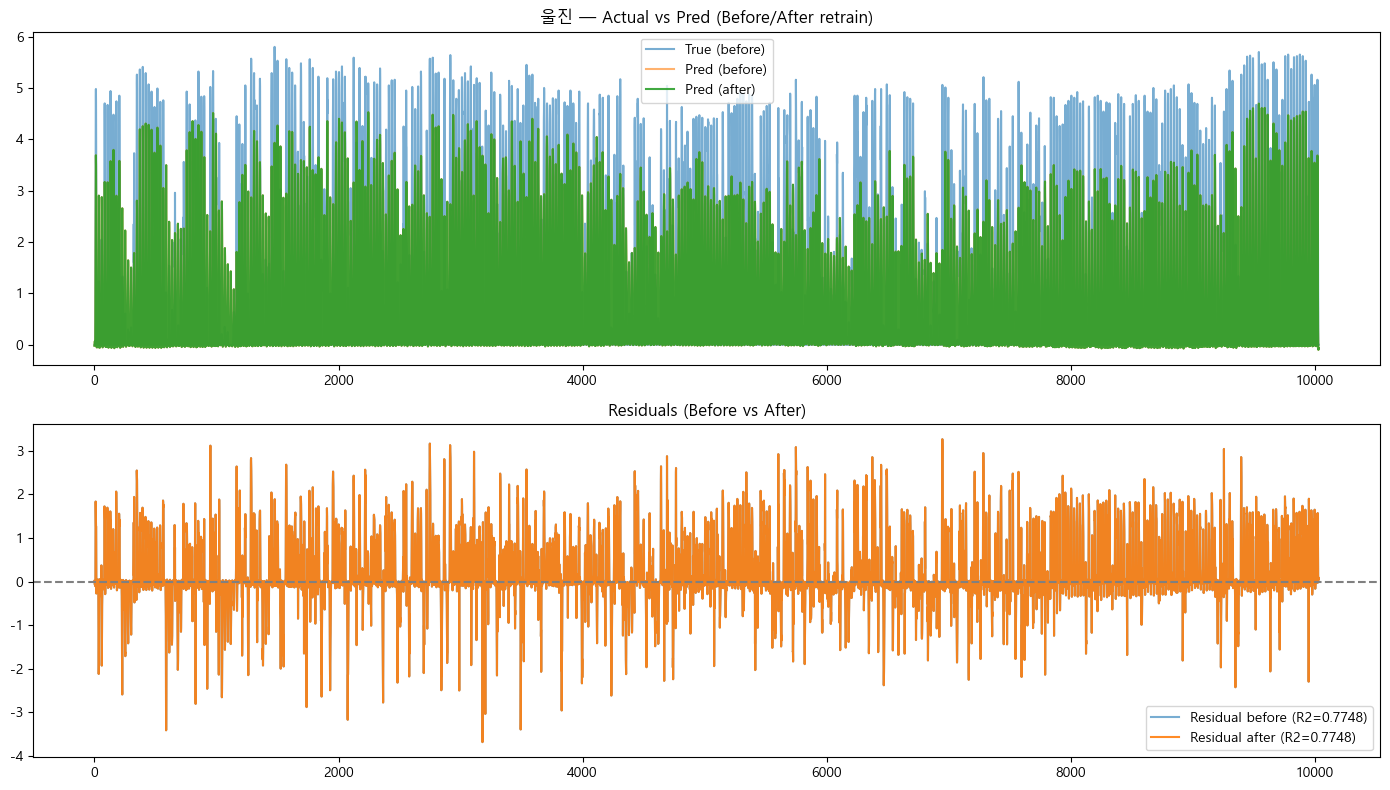

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 이천
[이천] Epoch 001 | Loss=0.259258 | Train R2=0.3980 | Val R2=0.6129 🎯
    ↪ 저장됨: 이천_initial_best.pth (Val R2=0.6129)
[이천] Epoch 002 | Loss=0.139399 | Train R2=0.7043 | Val R2=0.7139 🎯
    ↪ 저장됨: 이천_initial_best.pth (Val R2=0.7139)
[이천] Epoch 003 | Loss=0.120696 | Train R2=0.7417 | Val R2=0.7465 🎯
    ↪ 저장됨: 이천_initial_best.pth (Val R2=0.7465)
[이천] Epoch 004 | Loss=0.113283 | Train R2=0.7575 | Val R2=0.7609 🎯
    ↪ 저장됨: 이천_initial_best.pth (Val R2=0.7609)
[이천] Epoch 005 | Loss=0.107558 | Train R2=0.7692 | Val R2=0.7639 🎯
    ↪ 저장됨: 이천_initial_best.pth (Val R2=0.7639)
[이천] Epoch 006 | Loss=0.104480 | Train R2=0.7758 | Val R2=0.7750 🎯
    ↪ 저장됨: 이천_initial_best.pth (Val R2=0.7750)
[이천] Epoch 007 | Loss=0.102819 | Train R2=0.7795 | Val R2=0.7697
[이천] Epoch 008 | Loss=0.099904 | Train R2=0.7855 | Val R2=0.7797 🎯
    ↪ 저장됨: 이천_initial_b

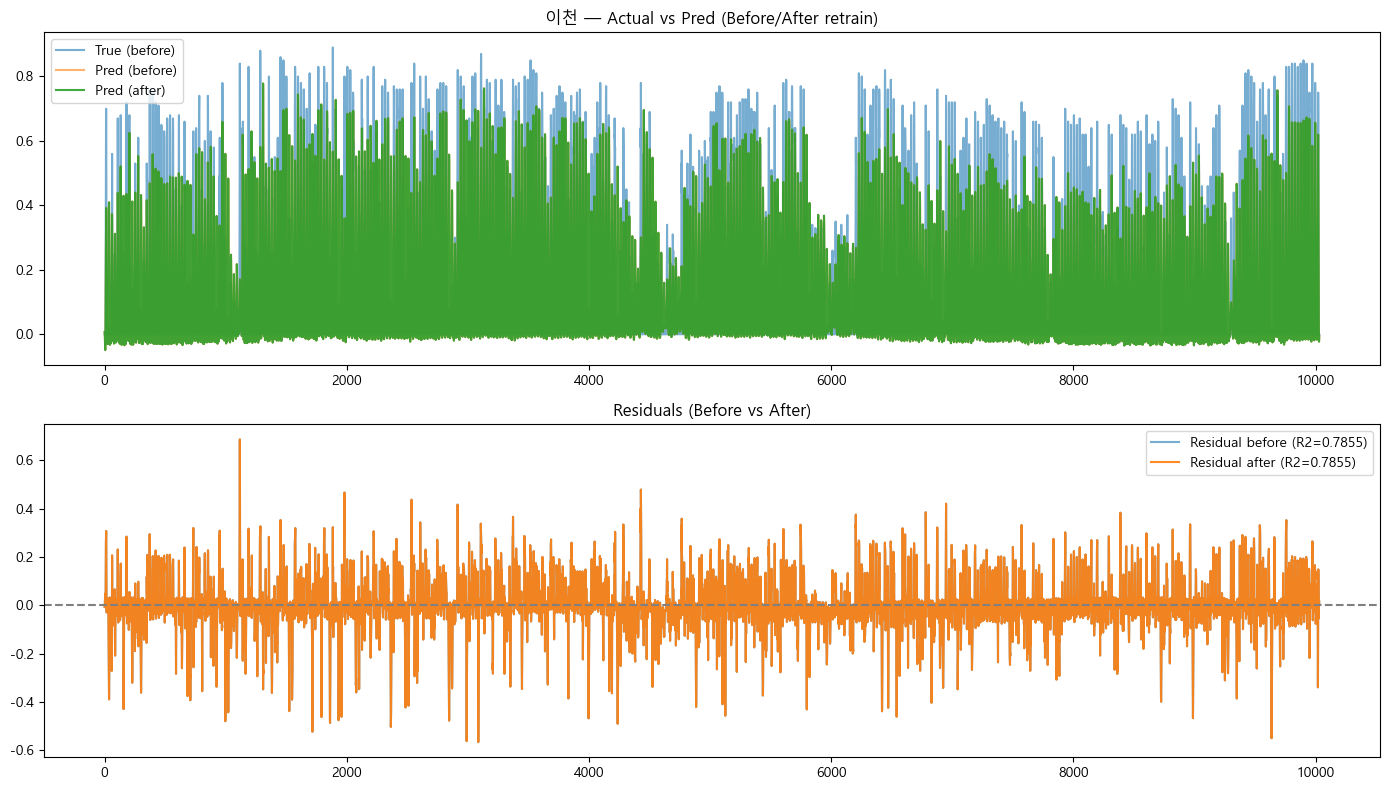

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 인천
[인천] Epoch 001 | Loss=0.134147 | Train R2=0.6719 | Val R2=0.6287 🎯
    ↪ 저장됨: 인천_initial_best.pth (Val R2=0.6287)
[인천] Epoch 002 | Loss=0.098496 | Train R2=0.7667 | Val R2=0.6320 🎯
    ↪ 저장됨: 인천_initial_best.pth (Val R2=0.6320)
[인천] Epoch 003 | Loss=0.090208 | Train R2=0.7864 | Val R2=0.6701 🎯
    ↪ 저장됨: 인천_initial_best.pth (Val R2=0.6701)
[인천] Epoch 004 | Loss=0.085203 | Train R2=0.7984 | Val R2=0.6697
[인천] Epoch 005 | Loss=0.084295 | Train R2=0.8011 | Val R2=0.6637
[인천] Epoch 006 | Loss=0.080548 | Train R2=0.8099 | Val R2=0.6644
[인천] Epoch 007 | Loss=0.081718 | Train R2=0.8076 | Val R2=0.6535
[인천] Epoch 008 | Loss=0.079616 | Train R2=0.8130 | Val R2=0.6527
[인천] Epoch 009 | Loss=0.076620 | Train R2=0.8204 | Val R2=0.6507
[인천] Epoch 010 | Loss=0.073913 | Train R2=0.8274 | Val R2=0.6150
⏸ [인천] Early stopping at epoch 10 (no val_

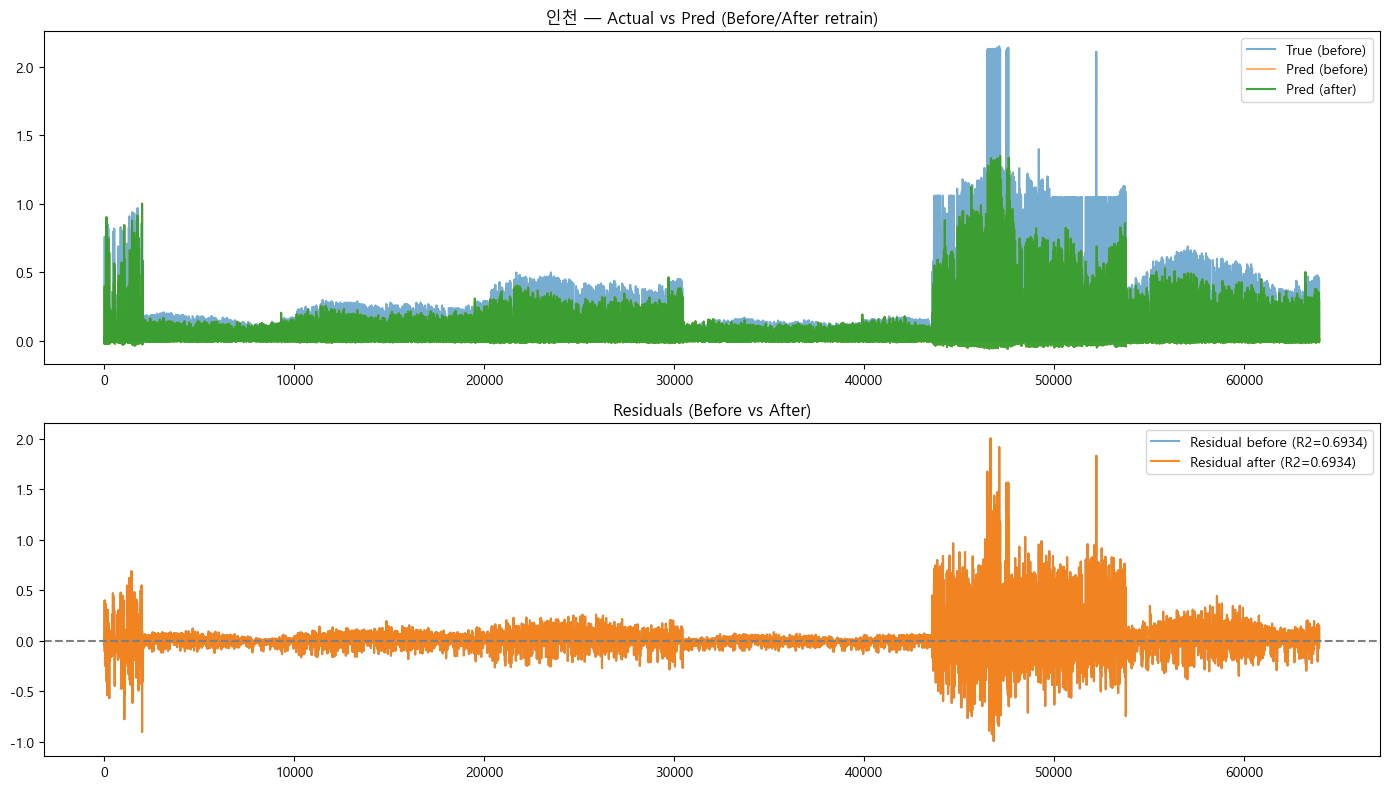

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

################################################################################
🌍 처리 시작: 충주
[충주] Epoch 001 | Loss=0.339312 | Train R2=0.0930 | Val R2=0.4099 🎯
    ↪ 저장됨: 충주_initial_best.pth (Val R2=0.4099)
[충주] Epoch 002 | Loss=0.225876 | Train R2=0.4696 | Val R2=0.5530 🎯
    ↪ 저장됨: 충주_initial_best.pth (Val R2=0.5530)
[충주] Epoch 003 | Loss=0.175143 | Train R2=0.6119 | Val R2=0.6461 🎯
    ↪ 저장됨: 충주_initial_best.pth (Val R2=0.6461)
[충주] Epoch 004 | Loss=0.142625 | Train R2=0.6865 | Val R2=0.6636 🎯
    ↪ 저장됨: 충주_initial_best.pth (Val R2=0.6636)
[충주] Epoch 005 | Loss=0.134108 | Train R2=0.7046 | Val R2=0.6705 🎯
    ↪ 저장됨: 충주_initial_best.pth (Val R2=0.6705)
[충주] Epoch 006 | Loss=0.127555 | Train R2=0.7187 | Val R2=0.7049 🎯
    ↪ 저장됨: 충주_initial_best.pth (Val R2=0.7049)
[충주] Epoch 007 | Loss=0.124287 | Train R2=0.7254 | Val R2=0.7005
[충주] Epoch 008 | Loss=0.120538 | Train R2=0.7331 | Val R2=0.7043
[충주] Epoch 009 | Loss=0.1

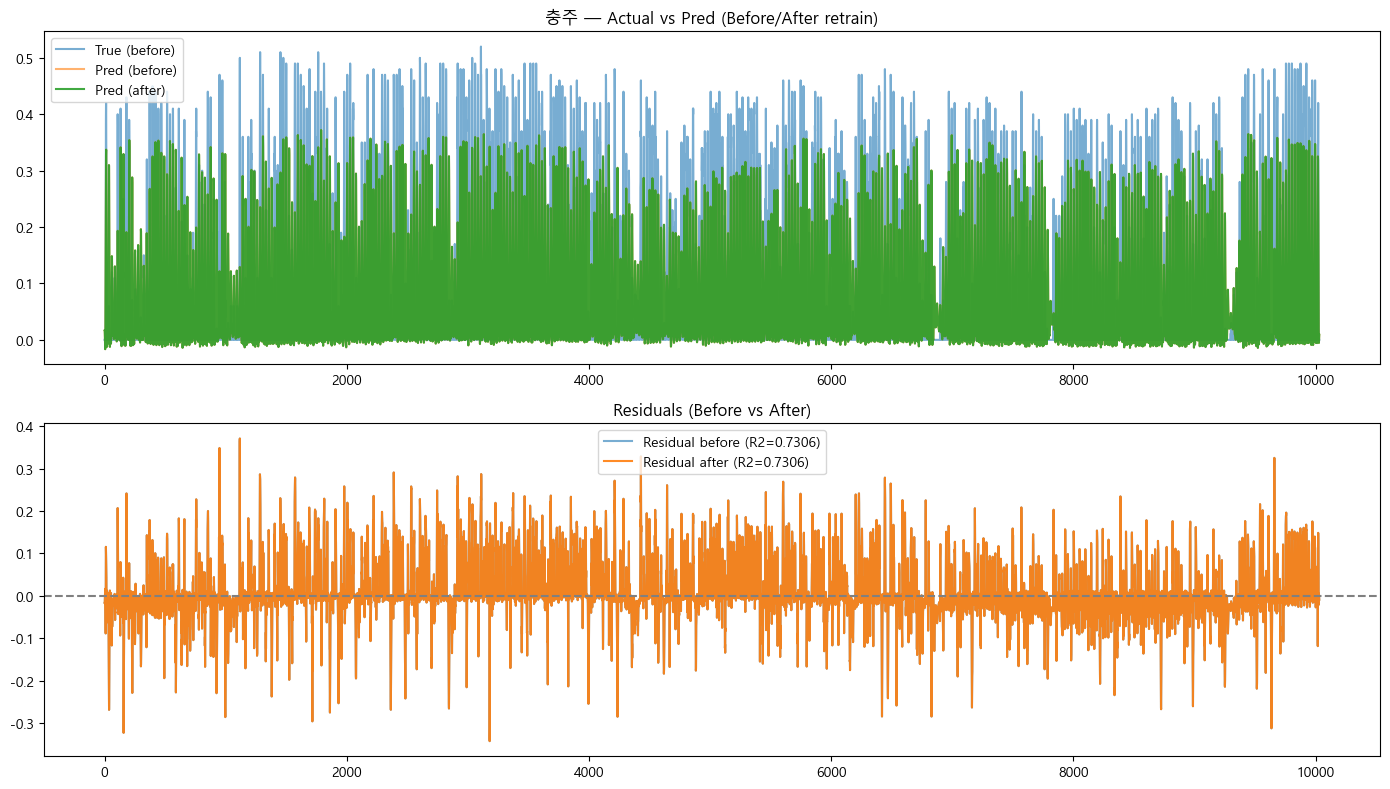

SHAP 계산 실패: cudnn RNN backward can only be called in training mode

✅ 모든 지역 처리 완료. HTML 리포트 생성 중...
🌐 HTML 리포트 생성 완료: C:\ESG_Project1\cnn_lstm\output\region_report_full.html


In [ ]:
# -*- coding: utf-8 -*-
"""
통합: CNN-BiLSTM + SHAP + HTML 리포트 (가중치 재학습 + Resume + test 출력 포함)
 - 고정: 사용자 제공된 feature / hyper 세팅 블록 그대로 사용
 - 개선: resume epoch 복원, log-R2 기준, 태양광 가중치 보정, ETA/로깅 강화, SHAP 안전 모드
"""
import os, math, warnings, base64, webbrowser, time, json, traceback
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn as nn, torch.optim as optim
from io import BytesIO
from jinja2 import Template
import shap

# ================================
# === 고정 설정 (사용자 제공 블록) ===
# ================================
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ================================
# === 사용자 설정 (경로 / 하이퍼파라미터) ===
# ================================
TRAIN_CSV = r"C:\ESG_Project1\file\merge_data\train.csv"
VAL_CSV   = r"C:\ESG_Project1\file\merge_data\val.csv"
TEST_CSV  = r"C:\ESG_Project1\file\merge_data\test.csv"
SAVE_DIR  = r"C:\ESG_Project1\cnn_lstm\output"
os.makedirs(SAVE_DIR, exist_ok=True)

TIME_COL, GROUP_COL, REGION_COL, TARGET_COL = "일시", "발전구분", "지역", "합산발전량(MWh)"
WEATHER_COLS = ["기온(°C)", "강수량(mm)", "일조(hr)", "일사(MJ/m2)"]
TIME_FEATS = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]

SEQ_LEN, HORIZON = 168, 24
BATCH = 128
EPOCHS = 50            # 전체 목표 epoch (resume 시 마지막 epoch 복원 후 남은 epoch 계산)
LR = 1e-3
PATIENCE = 7           # val R2 기준 patience
NUM_WORKERS = 0 if os.name=="nt" else 4
SMOOTH_WINDOW = 3
R2_THRESHOLD = 0.5     # 제외 기준 (요청값)
SHAP_SAMPLE = 200      # SHAP 계산 시 background sample 수 (메모리 고려)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (DEVICE.type=="cuda")

print(f"✅ Device: {DEVICE} | AMP: {use_amp}")

# ================================
# === 데이터 로드 및 피처 생성 ===
# ================================
train_raw = pd.read_csv(TRAIN_CSV, parse_dates=[TIME_COL])
val_raw   = pd.read_csv(VAL_CSV, parse_dates=[TIME_COL])
test_raw  = pd.read_csv(TEST_CSV, parse_dates=[TIME_COL])

def add_time_feats(df):
    df = df.copy()
    df.sort_values([GROUP_COL, TIME_COL], inplace=True)
    df["hour"] = df[TIME_COL].dt.hour
    df["doy"] = df[TIME_COL].dt.dayofyear
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["doy_sin"] = np.sin(2*np.pi*df["doy"]/365)
    df["doy_cos"] = np.cos(2*np.pi*df["doy"]/365)
    return df

for df in (train_raw, val_raw, test_raw):
    df[:] = add_time_feats(df)

LAGS = [1,3,6,24]
def add_lag_diff(df):
    df = df.copy()
    for lag in LAGS:
        df[f"lag_{lag}"] = df.groupby(GROUP_COL)[TARGET_COL].shift(lag)
        df[f"diff_{lag}"] = df[TARGET_COL] - df[f"lag_{lag}"]
    df.fillna(0, inplace=True)
    return df

train_raw = add_lag_diff(train_raw)
val_raw   = add_lag_diff(val_raw)
test_raw  = add_lag_diff(test_raw)

feature_cols = WEATHER_COLS + TIME_FEATS + [f"lag_{l}" for l in LAGS] + [f"diff_{l}" for l in LAGS]
# ============================================
# === (이후 코드 전반에서 feature_cols 고정) ===
# ============================================

# ================================
# === 그룹별 스케일링 (train 기반) ===
# ================================
region_scalers = {}
for region, grp in train_raw.groupby(REGION_COL):
    valid_cols = [c for c in feature_cols if c in grp.columns]
    if len(valid_cols) == 0:
        print(f"⚠ [{region}] 유효한 피처 없음 — 건너뜀")
        continue
    std = StandardScaler()
    mm = MinMaxScaler()
    X_std = std.fit_transform(grp[valid_cols].values)
    X_mm = mm.fit_transform(X_std)
    train_raw.loc[grp.index, valid_cols] = X_mm
    try:
        tsc = StandardScaler().fit(np.log1p(grp[[TARGET_COL]]))
        train_raw.loc[grp.index, TARGET_COL] = tsc.transform(np.log1p(grp[[TARGET_COL]]))
    except Exception as e:
        print(f"⚠ [{region}] 타깃 스케일러 생성 실패: {e}")
        tsc = None
    region_scalers[region] = (std, mm, tsc)

for df in (val_raw, test_raw):
    for region, grp in df.groupby(REGION_COL):
        valid_cols = [c for c in feature_cols if c in grp.columns]
        if len(valid_cols) == 0:
            print(f"⚠ [{region}] (val/test) 유효한 피처 없음 — 스킵")
            continue
        if region in region_scalers:
            std, mm, tsc = region_scalers[region]
            try:
                df.loc[grp.index, valid_cols] = mm.transform(std.transform(grp[valid_cols].values))
                if tsc is not None:
                    try:
                        df.loc[grp.index, TARGET_COL] = tsc.transform(np.log1p(grp[[TARGET_COL]]))
                    except Exception:
                        pass
            except Exception as e:
                print(f"⚠ [{region}] val/test 변환 실패: {e} — 로컬 스케일러 사용")
                df.loc[grp.index, valid_cols] = MinMaxScaler().fit_transform(grp[valid_cols].values)
        else:
            try:
                df.loc[grp.index, valid_cols] = MinMaxScaler().fit_transform(grp[valid_cols].values)
            except Exception as e:
                print(f"⚠ [{region}] unseen region 로컬 스케일링 실패: {e}")

# ================================
# === Dataset & Model 정의 ===
# ================================
class SequenceDataset(Dataset):
    def __init__(self, df, seq_len=SEQ_LEN, horizon=HORIZON, feature_cols=feature_cols, return_index=False, return_group=False):
        self.seq_len = seq_len
        self.horizon = horizon
        self.features = df[feature_cols].values.astype(np.float32)
        self.targets = df[TARGET_COL].values.astype(np.float32)
        # group per row (발전구분)
        # keep group for weighted training path
        self.groups = np.array(df[GROUP_COL].values) if GROUP_COL in df.columns else np.array(['']*len(df))
        self.index_arr = np.array(df.index)
        self.n_windows = max(0, len(df) - seq_len - horizon + 1)
        self.return_index = return_index
        self.return_group = return_group
    def __len__(self):
        return self.n_windows
    def __getitem__(self, i):
        x = self.features[i:i+self.seq_len]
        y = self.targets[i+self.seq_len:i+self.seq_len+self.horizon]
        start_idx = int(self.index_arr[i+self.seq_len])
        group = self.groups[i+self.seq_len] if len(self.groups)>0 else ""
        out = (torch.from_numpy(x), torch.from_numpy(y))
        if self.return_index and self.return_group:
            return out[0], out[1], start_idx, group
        elif self.return_index:
            return out[0], out[1], start_idx
        elif self.return_group:
            return out[0], out[1], group
        else:
            return out[0], out[1]

class CNN_BiLSTM(nn.Module):
    def __init__(self, input_dim=len(feature_cols), hidden=128, num_layers=2, horizon=HORIZON):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 128, 3, padding=1)
        self.conv2 = nn.Conv1d(128, 64, 3, padding=1)
        self.lstm = nn.LSTM(64, hidden, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden*2, horizon)
        self.relu = nn.ReLU()
        self.norm = nn.LayerNorm(hidden*2)
    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.permute(0,2,1)
        x,_ = self.lstm(x)
        x = self.norm(x[:,-1,:])
        return self.fc(x)

def safe_inverse_tsc(tsc, arr):
    try:
        return np.expm1(tsc.inverse_transform(arr.reshape(-1,1)).flatten())
    except Exception:
        # arr may already be in log space or so; fallback
        try:
            return np.expm1(arr)
        except Exception:
            return arr

# ================================
# === 유틸: log-R2 계산 함수 ===
# - 입력: 원본 true/pred (원래 단위, 음수 없다고 가정). 안전하게 clip 후 log1p로 변환하여 R2 계산.
# ================================
def log_r2(y_true, y_pred):
    # avoid negative predictions/true (clip)
    y_true_c = np.clip(y_true, a_min=0, a_max=None)
    y_pred_c = np.clip(y_pred, a_min=0, a_max=None)
    if len(y_true_c)==0:
        return float('nan')
    try:
        return r2_score(np.log1p(y_true_c), np.log1p(y_pred_c))
    except Exception:
        return float('nan')

# ================================
# === 유틸: 평가 함수 (dataset → 재조립 → 역변환 → 메트릭) ===
# ================================
def evaluate_on_df(model, df_region, region_name):
    true_avg, pred_smoothed = reassemble_predictions(model, df_region.reset_index(drop=True))
    if region_name in region_scalers:
        _, _, tsc = region_scalers[region_name]
        rec_true = np.full_like(true_avg, np.nan)
        if (~np.isnan(true_avg)).sum()>0:
            rec_true[~np.isnan(true_avg)] = safe_inverse_tsc(tsc, true_avg[~np.isnan(true_avg)])
        rec_pred = safe_inverse_tsc(tsc, pred_smoothed)
    else:
        rec_true, rec_pred = true_avg, pred_smoothed

    mask = ~np.isnan(rec_true) & ~np.isnan(rec_pred)
    if mask.sum()>0:
        r2_val = log_r2(rec_true[mask], rec_pred[mask])  # log-scale R2
        mae = mean_absolute_error(rec_true[mask], rec_pred[mask])
        rmse = math.sqrt(mean_squared_error(rec_true[mask], rec_pred[mask]))
        n = int(mask.sum())
    else:
        r2_val, mae, rmse, n = float('nan'), float('nan'), float('nan'), 0
    return {"r2":r2_val, "mae":mae, "rmse":rmse, "n":n}, rec_true, rec_pred

# ================================
# === Train 함수 (resume 가능한, val log-R2 기반 EarlyStopping) ===
# ================================
def train_region_model(train_df, val_df, region_tag, save_prefix, epochs=EPOCHS, resume=False):
    """
    epochs: 전체 목표 epoch (resume 시 len(history) 기준으로 남은 epoch 계산)
    resume: 체크포인트와 history 파일이 있으면 이어서 학습
    """
    model = CNN_BiLSTM().to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=LR)
    crit = nn.SmoothL1Loss()
    scaler = torch.amp.GradScaler(enabled=use_amp)

    best_path = os.path.join(SAVE_DIR, f"{save_prefix}_best.pth")
    hist_path = os.path.join(SAVE_DIR, f"{save_prefix}_history.json")
    history = []
    best_val_r2 = -np.inf
    patience_cnt = 0
    start_epoch = 1

    # resume: load history & best if available
    if resume and os.path.exists(hist_path):
        try:
            with open(hist_path, "r", encoding="utf-8") as hf:
                history = json.load(hf)
            if history:
                start_epoch = history[-1].get("epoch", len(history)) + 1
                # compute best_val_r2 from stored history (which is log-R2)
                best_val_r2 = max([h.get("val_r2", -1e9) for h in history])
            if os.path.exists(best_path):
                model.load_state_dict(torch.load(best_path, map_location=DEVICE))
            print(f"    ↪ Resume 로드: start_epoch={start_epoch}, best_val_r2={best_val_r2:.4f}, loaded history {len(history)} epochs")
        except Exception as e:
            print("⚠ Resume 로드 실패:", e)
            history = []
            start_epoch = 1

    # If resume and start_epoch > epochs => nothing to do
    if start_epoch > epochs:
        print(f"    ↪ 이미 목표 epoch({epochs}) 도달: start_epoch={start_epoch} > epochs -> 로드된 best를 반환")
        if os.path.exists(best_path):
            model.load_state_dict(torch.load(best_path, map_location=DEVICE))
        return model, history

    train_loader = DataLoader(SequenceDataset(train_df, return_group=False), batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(SequenceDataset(val_df, return_group=False), batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    epoch_times = []
    for ep in range(start_epoch, epochs+1):
        t0 = time.time()
        model.train()
        train_trues, train_preds = [], []
        total_loss = 0.0
        for batch in train_loader:
            xb, yb = batch
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                yp = model(xb)
                loss = crit(yp, yb)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            total_loss += float(loss.item()) * xb.size(0)
            train_trues.append(yb.detach().cpu().numpy()); train_preds.append(yp.detach().cpu().numpy())

        # train metrics: reconstruct arrays
        if len(train_trues)>0:
            train_trues = np.concatenate(train_trues).flatten()
            train_preds = np.concatenate(train_preds).flatten()
            # need to inverse-transform to original scale for log-R2/MAE/RMSE reporting
            if region_tag in region_scalers:
                _, _, tsc = region_scalers[region_tag]
                try:
                    true_orig = safe_inverse_tsc(tsc, train_trues)
                    pred_orig = safe_inverse_tsc(tsc, train_preds)
                except Exception:
                    true_orig = train_trues; pred_orig = train_preds
            else:
                true_orig = train_trues; pred_orig = train_preds
            train_r2_log = log_r2(true_orig, pred_orig)
            train_mae = mean_absolute_error(true_orig, pred_orig)
            train_rmse = math.sqrt(mean_squared_error(true_orig, pred_orig))
        else:
            train_r2_log, train_mae, train_rmse = float('nan'), float('nan'), float('nan')

        # validation
        model.eval()
        val_trues, val_preds = [], []
        with torch.no_grad():
            for batch in val_loader:
                xb, yb = batch
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                yp = model(xb)
                val_trues.append(yb.cpu().numpy()); val_preds.append(yp.cpu().numpy())
        if len(val_trues)>0:
            val_trues = np.concatenate(val_trues).flatten()
            val_preds = np.concatenate(val_preds).flatten()
            if region_tag in region_scalers:
                _, _, tsc = region_scalers[region_tag]
                try:
                    v_true_orig = safe_inverse_tsc(tsc, val_trues)
                    v_pred_orig = safe_inverse_tsc(tsc, val_preds)
                except Exception:
                    v_true_orig = val_trues; v_pred_orig = val_preds
            else:
                v_true_orig = val_trues; v_pred_orig = val_preds
            val_r2_log = log_r2(v_true_orig, v_pred_orig)
            val_mae = mean_absolute_error(v_true_orig, v_pred_orig)
            val_rmse = math.sqrt(mean_squared_error(v_true_orig, v_pred_orig))
        else:
            val_r2_log, val_mae, val_rmse = float('nan'), float('nan'), float('nan')

        avg_loss = total_loss / max(1, len(train_loader.dataset))
        history.append({"epoch":ep, "loss":avg_loss, "train_r2":train_r2_log, "train_mae":train_mae, "train_rmse":train_rmse,
                        "val_r2":val_r2_log, "val_mae":val_mae, "val_rmse":val_rmse})
        # persist history incrementally
        try:
            with open(hist_path, "w", encoding="utf-8") as hf:
                json.dump(history, hf, ensure_ascii=False, indent=2)
        except Exception:
            pass

        # best check by val_r2_log
        improved = (not np.isnan(val_r2_log)) and (val_r2_log > best_val_r2)
        if improved:
            best_val_r2 = val_r2_log
            patience_cnt = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_cnt += 1

        # time & ETA
        ep_time = time.time() - t0
        epoch_times.append(ep_time)
        avg_ep_time = np.mean(epoch_times[-10:])  # 최근 10 epoch 평균
        remaining = max(0, epochs - ep)
        eta = remaining * avg_ep_time

        star = " 🎯" if improved else ""
        print(f"[{region_tag}] Epoch {ep:03d}/{epochs} | Loss={avg_loss:.6f} | Train R2(log)={train_r2_log:.4f} | Val R2(log)={val_r2_log:.4f}{star} | MAE={val_mae:.3f} RMSE={val_rmse:.3f} | ETA={eta:.1f}s")

        if patience_cnt >= PATIENCE:
            print(f"⏸ [{region_tag}] Early stopping at epoch {ep} (no val_r2 improvement for {PATIENCE} epochs).")
            break

    # load best weights
    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    return model, history

# ================================
# === Weighted Train 함수 (샘플 가중치 적용, Resume 포함) ===
# ================================
def weighted_mse_loss_per_sample(pred, target, sample_weights):
    per_sample_mse = torch.mean((pred - target)**2, dim=1)  # (B, )
    weighted = per_sample_mse * sample_weights
    return torch.mean(weighted)

def train_region_model_with_weights(train_df, val_df, region_tag, save_prefix, plant_weights, epochs=EPOCHS, resume=False):
    """
    plant_weights: dict {plant_name: weight_float}
    epochs: 전체 목표 epoch
    resume: resume 동작 허용
    """
    model = CNN_BiLSTM().to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=LR)
    scaler = torch.amp.GradScaler(enabled=use_amp)

    best_path = os.path.join(SAVE_DIR, f"{save_prefix}_best_weighted.pth")
    hist_path = os.path.join(SAVE_DIR, f"{save_prefix}_history_weighted.json")
    history = []
    best_val_r2 = -np.inf
    patience_cnt = 0
    start_epoch = 1

    # resume load
    if resume and os.path.exists(hist_path):
        try:
            with open(hist_path, "r", encoding="utf-8") as hf:
                history = json.load(hf)
            if history:
                start_epoch = history[-1].get("epoch", len(history)) + 1
                best_val_r2 = max([h.get("val_r2", -1e9) for h in history])
            if os.path.exists(best_path):
                model.load_state_dict(torch.load(best_path, map_location=DEVICE))
            print(f"    ↪ Resume weighted 로드: start_epoch={start_epoch}, best_val_r2={best_val_r2:.4f}")
        except Exception as e:
            print("⚠ Resume weighted 로드 실패:", e)
            history = []
            start_epoch = 1

    if start_epoch > epochs:
        if os.path.exists(best_path):
            model.load_state_dict(torch.load(best_path, map_location=DEVICE))
        return model, history

    train_loader = DataLoader(SequenceDataset(train_df, return_group=True), batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(SequenceDataset(val_df, return_group=True), batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    def get_weight_array(groups):
        # groups: list/array of group names (strings)
        # map to dict, fallback 1.0
        arr = np.array([plant_weights.get(str(g), 1.0) for g in groups], dtype=np.float32)
        return torch.tensor(arr, device=DEVICE)

    epoch_times = []
    for ep in range(start_epoch, epochs+1):
        t0 = time.time()
        model.train()
        train_trues, train_preds = [], []
        total_loss = 0.0
        for batch in train_loader:
            xb, yb, groups = batch
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            with torch.autocast(device_type=DEVICE.type, enabled=use_amp):
                yp = model(xb)
                # groups might be numpy array of bytes/strings
                try:
                    groups_list = [g.decode() if isinstance(g, (bytes, np.bytes_)) else str(g) for g in groups]
                except Exception:
                    groups_list = [str(g) for g in groups]
                sample_weights = get_weight_array(groups_list)
                loss = weighted_mse_loss_per_sample(yp, yb, sample_weights)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            total_loss += float(loss.item()) * xb.size(0)
            train_trues.append(yb.detach().cpu().numpy()); train_preds.append(yp.detach().cpu().numpy())

        # train metrics (inverse for reporting)
        if len(train_trues)>0:
            train_trues = np.concatenate(train_trues).flatten()
            train_preds = np.concatenate(train_preds).flatten()
            if region_tag in region_scalers:
                _, _, tsc = region_scalers[region_tag]
                try:
                    true_orig = safe_inverse_tsc(tsc, train_trues)
                    pred_orig = safe_inverse_tsc(tsc, train_preds)
                except Exception:
                    true_orig = train_trues; pred_orig = train_preds
            else:
                true_orig = train_trues; pred_orig = train_preds
            train_r2_log = log_r2(true_orig, pred_orig)
            train_mae = mean_absolute_error(true_orig, pred_orig)
            train_rmse = math.sqrt(mean_squared_error(true_orig, pred_orig))
        else:
            train_r2_log, train_mae, train_rmse = float('nan'), float('nan'), float('nan')

        # validation
        model.eval()
        val_trues, val_preds = [], []
        with torch.no_grad():
            for batch in val_loader:
                xb, yb, groups = batch
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                yp = model(xb)
                val_trues.append(yb.cpu().numpy()); val_preds.append(yp.cpu().numpy())
        if len(val_trues)>0:
            val_trues = np.concatenate(val_trues).flatten()
            val_preds = np.concatenate(val_preds).flatten()
            if region_tag in region_scalers:
                _, _, tsc = region_scalers[region_tag]
                try:
                    v_true_orig = safe_inverse_tsc(tsc, val_trues)
                    v_pred_orig = safe_inverse_tsc(tsc, val_preds)
                except Exception:
                    v_true_orig = val_trues; v_pred_orig = val_preds
            else:
                v_true_orig = val_trues; v_pred_orig = val_preds
            val_r2_log = log_r2(v_true_orig, v_pred_orig)
            val_mae = mean_absolute_error(v_true_orig, v_pred_orig)
            val_rmse = math.sqrt(mean_squared_error(v_true_orig, v_pred_orig))
        else:
            val_r2_log, val_mae, val_rmse = float('nan'), float('nan'), float('nan')

        avg_loss = total_loss / max(1, len(train_loader.dataset))
        history.append({"epoch":ep, "loss":avg_loss, "train_r2":train_r2_log, "train_mae":train_mae, "train_rmse":train_rmse,
                        "val_r2":val_r2_log, "val_mae":val_mae, "val_rmse":val_rmse})
        try:
            with open(hist_path, "w", encoding="utf-8") as hf:
                json.dump(history, hf, ensure_ascii=False, indent=2)
        except Exception:
            pass

        improved = (not np.isnan(val_r2_log)) and (val_r2_log > best_val_r2)
        if improved:
            best_val_r2 = val_r2_log
            patience_cnt = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_cnt += 1

        # ETA
        ep_time = time.time() - t0
        epoch_times.append(ep_time)
        avg_ep_time = np.mean(epoch_times[-10:]) if epoch_times else ep_time
        remaining = max(0, epochs - ep)
        eta = remaining * avg_ep_time

        star = " 🎯" if improved else ""
        print(f"[{region_tag}][Weighted] Epoch {ep:03d}/{epochs} | Loss={avg_loss:.6f} | Train R2(log)={train_r2_log:.4f} | Val R2(log)={val_r2_log:.4f}{star} | MAE={val_mae:.3f} RMSE={val_rmse:.3f} | ETA={eta:.1f}s")

        if patience_cnt >= PATIENCE:
            print(f"⏸ [{region_tag}][Weighted] Early stopping at epoch {ep} (no val_r2 improvement for {PATIENCE} epochs).")
            break

    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, history

# ================================
# === 평가: 윈도우 → 원래 시계열 재조립 (겹침 평균) ===
# ================================
def reassemble_predictions(model, df_region):
    n = len(df_region)
    pred_sum = np.zeros(n, dtype=np.float64)
    pred_count = np.zeros(n, dtype=np.int32)
    true_sum = np.zeros(n, dtype=np.float64)
    true_count = np.zeros(n, dtype=np.int32)

    ds = SequenceDataset(df_region, return_index=True)
    loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)
    model.eval()
    with torch.no_grad():
        for batch in loader:
            if len(batch)==3:
                xb, yb, idxs = batch
            else:
                xb, yb = batch; idxs = None
            xb = xb.to(DEVICE)
            yp = model(xb).cpu().numpy()
            yb_np = yb.numpy()
            if idxs is None:
                continue
            for j, start_idx in enumerate(idxs.numpy()):
                s = int(start_idx); e = s + HORIZON
                if s<0 or e>n: continue
                pred_sum[s:e] += yp[j]; pred_count[s:e] += 1
                true_sum[s:e] += yb_np[j]; true_count[s:e] += 1

    pred_avg = np.full(n, np.nan, dtype=np.float64)
    true_avg = np.full(n, np.nan, dtype=np.float64)
    mask = pred_count>0
    pred_avg[mask] = pred_sum[mask] / pred_count[mask]
    maskt = true_count>0
    true_avg[maskt] = true_sum[maskt] / true_count[maskt]

    pred_series = pd.Series(pred_avg)
    pred_series = pred_series.interpolate().fillna(method='ffill').fillna(method='bfill')
    pred_smoothed = pred_series.rolling(SMOOTH_WINDOW, min_periods=1, center=True).mean().values

    return true_avg, pred_smoothed

# ================================
# === 발전소(그룹)별 R2 계산 + 진단 그래프/원인분석 ===
# ================================
def per_plant_diagnose(model, region_train_df, region_val_df, region_test_df, region_name, eval_on="val"):
    """
    eval_on: 'val' 또는 'test' (기본 'val') — 발전소별 R2 계산에 활용될 데이터셋 선택
    """
    records = []
    low_plants = []
    eval_df = region_val_df if eval_on=="val" else region_test_df
    for plant, grp in eval_df.groupby(GROUP_COL):
        if len(grp) < SEQ_LEN + HORIZON:
            continue
        true_avg, pred_smoothed = reassemble_predictions(model, grp.reset_index(drop=True))
        if region_name in region_scalers:
            _, _, tsc = region_scalers[region_name]
            recovered_true = np.full_like(true_avg, np.nan)
            if (~np.isnan(true_avg)).sum()>0:
                recovered_true[~np.isnan(true_avg)] = safe_inverse_tsc(tsc, true_avg[~np.isnan(true_avg)])
            recovered_pred = safe_inverse_tsc(tsc, pred_smoothed)
        else:
            recovered_true = true_avg
            recovered_pred = pred_smoothed

        valid_mask = ~np.isnan(recovered_true) & ~np.isnan(recovered_pred)
        if valid_mask.sum()==0:
            continue
        y_true = recovered_true[valid_mask]; y_pred = recovered_pred[valid_mask]
        r2 = log_r2(y_true, y_pred)  # log-scale R2 per-plant
        mae = mean_absolute_error(y_true, y_pred)
        rmse = math.sqrt(mean_squared_error(y_true, y_pred))
        records.append({"발전구분":plant, "R2":r2, "MAE":mae, "RMSE":rmse, "n":len(y_true)})

        if r2 < R2_THRESHOLD:
            low_plants.append(plant)
            fig, ax = plt.subplots(2,1, figsize=(12,6))
            ax[0].plot(y_true, label="실제값", alpha=0.8)
            ax[0].plot(y_pred, label="예측값", alpha=0.8)
            ax[0].set_title(f"[저성능] 지역={region_name} | 발전소={plant} | log-R2={r2:.4f} | n={len(y_true)}")
            ax[0].legend()
            residuals = y_true - y_pred
            ax[1].plot(residuals, label="Residuals", alpha=0.8)
            ax[1].axhline(0, color='gray', linestyle='--')
            ax[1].set_title("잔차")
            ax[1].legend()
            plt.tight_layout()
            plt.show()

            # 자동 원인 분석
            print(f"🔍 원인 분석 — {region_name} / {plant}")
            print(f"   • True mean={np.mean(y_true):.3f}, std={np.std(y_true):.3f}, skew={pd.Series(y_true).skew():.3f}")
            print(f"   • MAE={mae:.3f}, RMSE={rmse:.3f}")
            time_idx = np.arange(len(residuals))
            if len(residuals)>3:
                trend_corr = np.corrcoef(time_idx, residuals)[0,1]
            else:
                trend_corr = 0.0
            if abs(trend_corr) > 0.4:
                print("   • 잔차와 시간 상관 존재 → Concept drift 또는 추세 미반영 의심")
            spikes = np.mean(np.abs(residuals) > 3*np.std(residuals))
            if spikes > 0.05:
                print("   • 잔차에 큰 스파이크 비중이 높음 → 라벨 이상 가능성")
            print("   • 제안: 데이터 품질 확인, 입력 피처 보강, 발전소별 모델 검토\n")

    plant_df = pd.DataFrame(records).sort_values("R2")
    return plant_df, low_plants

# ================================
# === 메인: 지역 루프 (초기 학습 → 진단(val) → 가중치 계산 → 가중치 재학습 → 비교(test 포함) → SHAP/HTML) ===
# ================================
region_reports = []

for region, train_grp in train_raw.groupby(REGION_COL):
    try:
        print("\n" + "#"*80)
        print(f"🌍 처리 시작: {region}")
        val_grp = val_raw[val_raw[REGION_COL]==region].reset_index(drop=True)
        test_grp = test_raw[test_raw[REGION_COL]==region].reset_index(drop=True)
        train_grp = train_grp.reset_index(drop=True)

        if len(train_grp) < SEQ_LEN + HORIZON or len(val_grp) < SEQ_LEN + HORIZON:
            print(f"⚠ 데이터 부족: train={len(train_grp)}, val={len(val_grp)} → 스킵")
            continue

        # 1) 초기 학습 (resume 가능)
        prefix_initial = f"{region}_initial"
        model_initial, hist_initial = train_region_model(train_grp, val_grp, region, prefix_initial, epochs=EPOCHS, resume=True)

        # 2) 발전소별 진단 (val 기준)
        plant_df_val, low_plants_val = per_plant_diagnose(model_initial, train_grp, val_grp, val_grp, region, eval_on="val")
        print(f"[{region}] Val 기준 발전소별 요약 (하위 10):")
        if not plant_df_val.empty:
            display_df = plant_df_val.sort_values("R2").head(10).copy()
            print(display_df.to_string(index=False))
        else:
            print("  • 평가 가능한 발전소 없음 (val)")

        # 3) 발전소별 가중치 계산 (val R2 기반, 태양광 보정 포함)
        plant_weights = {}
        if not plant_df_val.empty:
            min_r2 = plant_df_val["R2"].min()
            max_r2 = plant_df_val["R2"].max()
            denom = max(1e-6, (max_r2 - min_r2))
            plant_df_val["r2_norm"] = (plant_df_val["R2"] - min_r2) / denom  # 0..1 (low->0)
            # raw weight: low R2 -> bigger weight (1 - r2_norm)
            plant_df_val["weight_raw"] = 1.0 - plant_df_val["r2_norm"]

            # 태양광 보정: 발전소별 평균 일사(있다면) 사용
            if "일사(MJ/m2)" in train_grp.columns:
                # compute per-plant mean irradiance on val set (safe)
                irr_means = val_grp.groupby(GROUP_COL)["일사(MJ/m2)"].mean()
                # normalize
                mm = MinMaxScaler()
                irr_vals = irr_means.reindex(plant_df_val["발전구분"]).fillna(0).values.reshape(-1,1)
                try:
                    irr_norm = mm.fit_transform(irr_vals).flatten()
                except Exception:
                    irr_norm = np.zeros_like(irr_vals).flatten()
                # 보정: irradiance 낮은 발전소에 약간 더 가중치 부여(어려움 보정)
                plant_df_val["irr_norm"] = irr_norm
                # correction factor: 1 + 0.5*(1 - irr_norm)
                plant_df_val["irr_correction"] = 1.0 + 0.5*(1.0 - plant_df_val["irr_norm"])
            else:
                plant_df_val["irr_correction"] = 1.0

            # map weight_raw * irr_correction to [0.2, 2.0]
            plant_df_val["weight"] = 0.2 + (plant_df_val["weight_raw"] * plant_df_val["irr_correction"]).clip(0,1) * (2.0 - 0.2)
            # ensure no zero
            plant_df_val["weight"] = plant_df_val["weight"].replace(0, 0.2)

            plant_weights = dict(zip(plant_df_val["발전구분"].astype(str), plant_df_val["weight"].astype(float)))

        print(f"🔢 [{region}] 발전소별 학습 가중치 (샘플 가중치) 요약 (최대 30):")
        for p, w in list(plant_weights.items())[:30]:
            try:
                r2_val = plant_df_val.loc[plant_df_val['발전구분']==p,'R2'].values[0]
            except Exception:
                r2_val = None
            print(f"   {p:<20} weight={w:.3f} (val log-R2={r2_val})")
        if len(plant_weights)==0:
            print("   • 가중치 정보 없음 → 기본값 사용(1.0)")

        # 4) 가중치 기반 재학습 (resume 허용)
        prefix_weighted = f"{region}_weighted"
        model_weighted, hist_weighted = train_region_model_with_weights(train_grp, val_grp, region, prefix_weighted, plant_weights, epochs=EPOCHS, resume=True)

        # 5) 재학습 전/후 test 성능 계산 및 출력 (log-R2 기준)
        test_metrics_init, rec_true_init, rec_pred_init = evaluate_on_df(model_initial, test_grp, region)
        print(f"📊 [{region}] Test (initial) — log-R2={test_metrics_init['r2']:.4f} | MAE={test_metrics_init['mae']:.4f} | RMSE={test_metrics_init['rmse']:.4f} | n={test_metrics_init['n']}")
        test_metrics_weighted, rec_true_w, rec_pred_w = evaluate_on_df(model_weighted, test_grp, region)
        print(f"📊 [{region}] Test (weighted) — log-R2={test_metrics_weighted['r2']:.4f} | MAE={test_metrics_weighted['mae']:.4f} | RMSE={test_metrics_weighted['rmse']:.4f} | n={test_metrics_weighted['n']}")

        # 6) 재학습 전/후 비교 시각화 (test 기준)
        mask_init = ~np.isnan(rec_true_init) & ~np.isnan(rec_pred_init)
        mask_w = ~np.isnan(rec_true_w) & ~np.isnan(rec_pred_w)

        fig, ax = plt.subplots(2,1, figsize=(14,8))
        if mask_init.sum()>0:
            ax[0].plot(rec_true_init[mask_init], label="True (test)", alpha=0.6)
            ax[0].plot(rec_pred_init[mask_init], label="Pred (initial)", alpha=0.6)
        if mask_w.sum()>0:
            ax[0].plot(rec_pred_w[mask_w], label="Pred (weighted)", alpha=0.9)
        ax[0].set_title(f"{region} — Actual vs Pred (Test: initial vs weighted)")
        ax[0].legend()

        if mask_init.sum()>0:
            res_init = rec_true_init[mask_init] - rec_pred_init[mask_init]
            ax[1].plot(res_init, label=f"Residual initial (log-R2={test_metrics_init['r2']:.4f})", alpha=0.6)
        if mask_w.sum()>0:
            res_w = rec_true_w[mask_w] - rec_pred_w[mask_w]
            ax[1].plot(res_w, label=f"Residual weighted (log-R2={test_metrics_weighted['r2']:.4f})", alpha=0.9)
        ax[1].axhline(0, color='gray', linestyle='--')
        ax[1].set_title("Residuals (initial vs weighted) on Test")
        ax[1].legend()
        plt.tight_layout()
        plt.show()

        # 7) SHAP: cuDNN 회피 + no_grad 안전 모드
        shap_img_b64 = None
        try:
            model_for_shap = model_weighted
            model_for_shap.eval()
            torch.backends.cudnn.enabled = False

            sample_df = train_grp.sample(n=min(SHAP_SAMPLE, len(train_grp)), random_state=42) if len(train_grp)>0 else train_grp
            sample_ds = SequenceDataset(sample_df.reset_index(drop=True))
            sample_windows = []
            for i in range(min(50, sample_ds.n_windows)):
                xb, _ = sample_ds[i]
                sample_windows.append(xb.numpy())
            if len(sample_windows)==0:
                sample_windows = np.zeros((1, SEQ_LEN, len(feature_cols)), dtype=np.float32)
            background = torch.tensor(np.stack(sample_windows)).to(DEVICE)

            # GradientExplainer로 안정적 SHAP 계산 (no_grad로 래핑)
            with torch.no_grad():
                explainer = shap.GradientExplainer(model_for_shap, background)
                shap_values = explainer.shap_values(background)

            shap_mean = np.mean(np.abs(shap_values), axis=(0,1))
            plt.figure(figsize=(10,6))
            plt.barh(feature_cols, shap_mean)
            plt.title(f"{region} — 평균 SHAP 중요도")
            plt.tight_layout()
            buf = BytesIO()
            plt.savefig(buf, format="png")
            plt.close()
            shap_img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
            buf.close()
            torch.backends.cudnn.enabled = True
        except Exception as e:
            print(f"⚠ SHAP 계산 실패: {e}")
            traceback.print_exc()
            torch.backends.cudnn.enabled = True

        # 8) 리포트용 데이터 모음
        region_reports.append({
            "region": region,
            "before_r2": float(test_metrics_init["r2"]) if test_metrics_init["n"]>0 else None,
            "after_r2": float(test_metrics_weighted["r2"]) if test_metrics_weighted["n"]>0 else None,
            "before_mae": float(test_metrics_init["mae"]) if test_metrics_init["n"]>0 else None,
            "after_mae": float(test_metrics_weighted["mae"]) if test_metrics_weighted["n"]>0 else None,
            "plant_df": plant_df_val,
            "plant_weights": plant_weights,
            "low_plants": low_plants_val,
            "shap_img": shap_img_b64,
            "hist_initial": hist_initial,
            "hist_weighted": hist_weighted
        })

    except Exception as e:
        print(f"⚠ [{region}] 처리 중 예외: {e}")
        traceback.print_exc()

print("\n✅ 모든 지역 처리 완료. HTML 리포트 생성 중...")

# ================================
# === HTML 리포트 통합 생성 ===
# ================================
html_template = """
<html><head><meta charset="utf-8"><title>지역별 모델 리포트</title></head><body>
<h1>지역별 학습/가중치 재학습 요약 (log-R2 기준)</h1>
{% for s in summaries %}
  <h2>{{s.region}}</h2>
  <p>Test log-R2 (before → weighted after): {{'N/A' if s.before_r2 is none else '%.4f' % s.before_r2}} → {{'N/A' if s.after_r2 is none else '%.4f' % s.after_r2}}</p>
  <p>Test MAE (before → weighted after): {{'N/A' if s.before_mae is none else '%.3f' % s.before_mae}} → {{'N/A' if s.after_mae is none else '%.3f' % s.after_mae}}</p>
  <p>저성능 발전소 (log-R2 < {{thresh}}) [val 기준]: {{s.low_plants}}</p>
  <h4>발전소별 가중치 (val log-R2 기반)</h4>
  <table border="1" cellpadding="4">
    <tr><th>발전구분</th><th>Val log-R2</th><th>Weight</th></tr>
    {% for _, row in s.plant_df.sort_values('R2').iterrows() %}
      <tr><td>{{row['발전구분']}}</td><td>{{'%.4f' % row['R2']}}</td><td>{{'%.3f' % s.plant_weights.get(row['발전구분'], 1.0)}}</td></tr>
    {% endfor %}
  </table>
  {% if s.shap_img %}
    <h4>SHAP (샘플)</h4>
    <img src="data:image/png;base64,{{s.shap_img}}" style="max-width:900px;">
  {% endif %}
  <hr>
{% endfor %}
</body></html>
"""

html_path = os.path.join(SAVE_DIR, "region_report_weighted_full.html")
with open(html_path, "w", encoding="utf-8") as f:
    f.write(Template(html_template).render(summaries=region_reports, thresh=R2_THRESHOLD))

webbrowser.open("file://"+html_path)
print(f"🌐 HTML 리포트 생성 완료: {html_path}")
